## (Symbolic Regression) Experiment 1 - Binary Star / Galaxy Classification

## Star-Galaxy Classification (Experiment 1) using PySR. We are using spectroscopic redshift (z) as input.


In [1]:
# Step 0 — Imports & global configuration

import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import sympy as sp
from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    cohen_kappa_score, confusion_matrix, f1_score,
    precision_recall_fscore_support, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

from pysr import PySRRegressor

warnings.filterwarnings('ignore', category=RuntimeWarning)

RESULTS_DIR = Path('Ex1_SR_SG')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Modeling knobs
RANDOM_STATE   = 42
# Binary classification only: STAR and GALAXY. QSO is dropped at the .isin
# filter in Step 1 because it is not in CLASSES. Display order is
# GALAXY -> STAR so confusion-matrix rows/cols read in that order.
CLASSES        = ['GALAXY', 'STAR']

# Binary ordinal encoding kept as STAR=0, GALAXY=1 — independent of the
# display order above. This keeps PySR fitting a monotone-in-z target
# (STAR at z~0 gets the lowest ord, GALAXY at low/intermediate z gets the
# higher ord), which yields a simpler discovered equation.
# A single threshold t on the symbolic score s(z) implements the decision:
#   s(z) <  t  ->  STAR
#   s(z) >= t  ->  GALAXY
LABEL_TO_ORD   = {'STAR': 0, 'GALAXY': 1}
ORD_TO_LABEL   = {v: k for k, v in LABEL_TO_ORD.items()}

# Ordinal indices in the DISPLAY order from `CLASSES`. Used everywhere
# sklearn expects `labels=...`. Under CLASSES=['GALAXY','STAR'] with the
# SG encoding above this is [1, 0] — sklearn then puts GALAXY in row/col 0
# and STAR in row/col 1 of the confusion matrix.
LABEL_ORDER    = [LABEL_TO_ORD[c] for c in CLASSES]
COMPLEXITY_CAP = 10
N_FOLDS        = 5
PYSR_NITER     = 500

# ---- Plot aesthetics ------------------------------------------
PALETTE = {
    'STAR':   {'color': '#d62728', 'marker': 'o'},
    'GALAXY': {'color': '#1f4e79', 'marker': 's'},
}
FIGSIZE_SINGLE = (7.0, 5.0)
FIGSIZE_DOUBLE = (13.5, 5.0)

sns.set_style('white')
plt.rcParams.update({
    'figure.dpi':           150, 'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'figure.facecolor':     'white', 'savefig.facecolor':    'white',
    'font.family':          'DejaVu Sans', 'font.size':            11,
    'axes.titlesize':       14, 'axes.titleweight':     'bold',
    'axes.labelsize':       13, 'axes.labelweight':     'normal',
    'axes.spines.top':      True, 'axes.spines.right':    True,
    'axes.spines.bottom':   True, 'axes.spines.left':     True,
    'axes.edgecolor':       'black', 'axes.linewidth':       1.2,
    'xtick.direction':      'in', 'ytick.direction':      'in',
    'xtick.top':            True, 'ytick.right':          True,
    'xtick.major.size':     5.5, 'ytick.major.size':     5.5,
    'xtick.minor.size':     3.0, 'ytick.minor.size':     3.0,
    'xtick.major.width':    1.0, 'ytick.major.width':    1.0,
    'xtick.minor.width':    0.8, 'ytick.minor.width':    0.8,
    'xtick.minor.visible':  True, 'ytick.minor.visible':  True,
    'xtick.labelsize':      11, 'ytick.labelsize':      11,
    'xtick.color':          'black', 'ytick.color':          'black',
    'axes.grid':            False,
    'grid.alpha':           0.25, 'grid.linestyle':       ':', 'grid.color':           '0.5',
    'legend.fontsize':      11, 'legend.framealpha':    0.95,
    'legend.edgecolor':     'black', 'legend.fancybox':      False,
    'lines.linewidth':      2.4, 'lines.markersize':     8,
})


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Step 1 — Load and clean the catalog

Keep only the columns we actually use, standardize the `QUASAR` label to
`QSO`, drop rows missing class or redshift, and map class names to ordinal
integers:

$$y \;=\; \begin{cases} 0 & \text{STAR}\\ 1 & \text{GALAXY}\end{cases}$$

The ordinal encoding is what the regression target will use.

In [2]:
CSV_PATH = 'photofeatures_exp1.csv'
df = pd.read_csv(CSV_PATH)
df['class'] = df['class'].astype(str).str.upper().replace({'QUASAR': 'QSO'})
df = df.dropna(subset=['class', 'redshift']).reset_index(drop=True)
df = df[df['class'].isin(CLASSES)].reset_index(drop=True)
df['y_ord'] = df['class'].map(LABEL_TO_ORD).astype(int)
print(f'Rows after cleaning: {len(df):,}')
print(df['class'].value_counts().to_string())
df.head()


Rows after cleaning: 159,999
class
STAR      80000
GALAXY    79999


,objid,specobjid,class,run,rerun,camcol,field,ra,dec,redshift,...,extinction_i,dered_z,deVRad_z,psffwhm_z,extinction_z,u_g,g_r,r_i,i_z,y_ord
0,1237648722849103923,3.266346e+18,STAR,756,301,6,547,197.702223,1.148042,0.000014,...,0.060744,14.78726,0.079178,1.513590,0.045182,1.576280,0.602839,0.213771,0.094666,0
1,1237662638525973600,2.850798e+18,STAR,3996,301,6,285,247.122225,8.406869,0.000239,...,0.088465,19.76877,0.000668,1.296406,0.065802,4.268986,0.759411,0.382273,0.153618,0
2,1237661149771727186,8.363376e+18,GALAXY,3650,301,1,114,208.138670,46.435733,0.359694,...,0.034025,19.86892,0.236196,1.315203,0.025308,0.777061,0.761957,0.274605,0.582960,1
3,1237664093976003377,1.175673e+19,GALAXY,4335,301,5,178,136.554526,29.616324,0.863170,...,0.051600,21.13619,0.028966,1.128623,0.038381,-0.003134,0.321045,0.414448,0.465267,1
4,1237680481416774149,8.716829e+18,GALAXY,8151,301,1,72,4.601796,29.080451,0.708177,...,0.055829,19.65644,0.838330,1.284192,0.041526,2.783092,0.906183,1.152702,0.717501,1


## Step 2 — Class distribution

Quick sanity check that the two classes are present in roughly equal numbers — this is a *balanced* catalogue. 


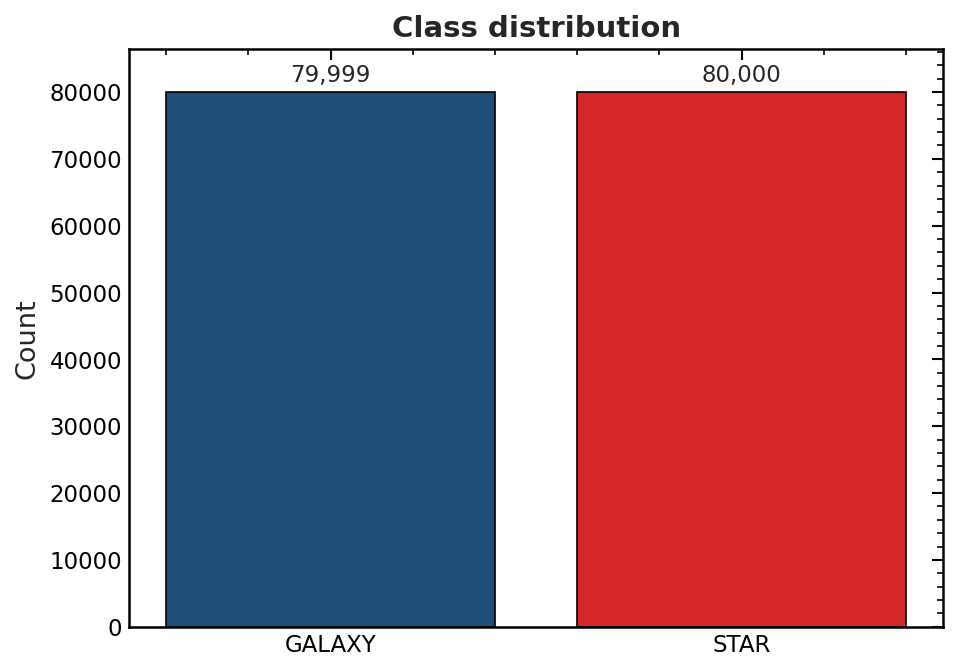

In [3]:
counts = df['class'].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c]['color'] for c in CLASSES],
              edgecolor='black', linewidth=0.8)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.01, f'{v:,}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Class distribution')
ax.set_ylim(0, max(counts.values) * 1.08)
fig.savefig(RESULTS_DIR / 'class_distribution.png')
plt.show()


## Step 3 — Redshift distribution per class (log y)

The three populations occupy distinct redshift regimes:

- **Stars** form a tight peak at $z \approx 0$ (Galactic foreground).
- **Galaxies** span roughly $z \in [0.05,\ 1.0]$.
- **Quasars** start at $z \approx 0.5$ and tail out past $z \approx 7$.

This 1-D separability is exactly what symbolic regression will exploit: there *exists* a low-complexity analytic $s(z)$ that orders the three populations along the score axis. The log y-axis is used so both the stellar locus and the long QSO tail remain visible at the same time.


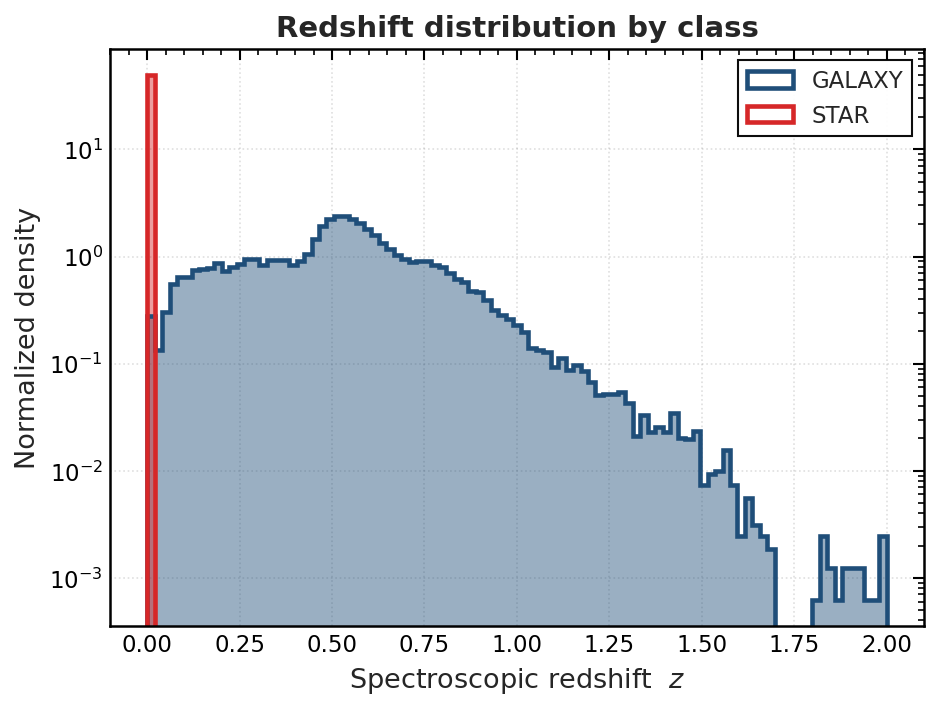

In [4]:
zmax = float(np.quantile(df['redshift'], 1.0))
bins = np.linspace(0, zmax, 100)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = df.loc[df['class'] == name, 'redshift']
    ax.hist(sub, bins=bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.set_yscale('log')
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('Normalized density')
ax.set_title('Redshift distribution by class')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend()
fig.savefig(RESULTS_DIR / 'redshift_distribution.png')
plt.show()


## Step 4 — Colour vs. redshift

A 2-D look at what a redshift-only classifier is *not* using. Stars track
a narrow horizontal locus near $z = 0$, galaxies occupy a stable colour
band across their z-range, and quasars exhibit strong colour evolution at
both ends of the z-axis. This is informative but not part of the model —
$s(z)$ stays one-dimensional.

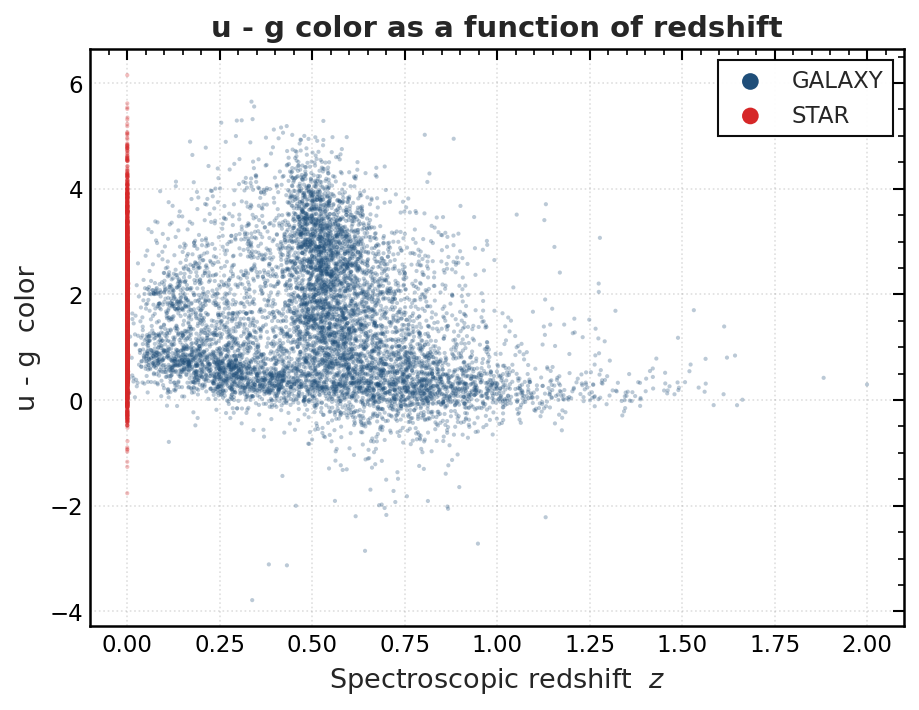

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    sub = df[df['class'] == name]
    take = min(8_000, len(sub))
    sub = sub.sample(n=take, random_state=RANDOM_STATE)
    ax.scatter(sub['redshift'], sub['u_g'], s=4, alpha=0.30,
               color=PALETTE[name]['color'], label=name, edgecolor='none')
# ax.set_xlim(-0.05, float(np.quantile(df['redshift'], 0.99)) * 1.05)
# ax.set_ylim(np.quantile(df['u_g'], 0.005), np.quantile(df['u_g'], 0.995))
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('u - g  color')
ax.set_title('u - g color as a function of redshift')
ax.grid(True, alpha=0.25, linestyle=':')
leg = ax.legend(loc='upper right', markerscale=4, framealpha=0.95)
for h in leg.legend_handles: h.set_alpha(1.0)
fig.savefig(RESULTS_DIR / 'ug_vs_z.png')
plt.show()


## Step 5 — Train / val / test split

Total dataset is partitioned into:

| Split | Fraction | Role |
| --- | --- | --- |
| TRAIN | 12.5 % | PySR sees this. Sub-split 50/50: |
|   ↳ `train_structure` | 6.25 % | PySR fits the symbolic search on this set. |
|   ↳ `train_optimize`  | 6.25 % | Constants of every Pareto candidate are refit on this set via L-BFGS. |
| VAL | 75 % | Used downstream for selection, calibration, and CV. Sub-split: |
|   ↳ `val_rerank`     | 12.5 % | Pareto re-rank (pick the equation). |
|   ↳ `val_cv`         | 62.5 %  | 5-fold cross-validation. **No train data enters CV.** |
| TEST | 12.5 % | Held-out, touched once at the end. |

All splits are stratified by class.


In [6]:
X       = df[['redshift']].values.astype(float)
dnnx    = df[['u_g', 'g_r', 'r_i', 'i_z']].values.astype(float)
y       = df['y_ord'].values.astype(int)
objlist = df['objid'].values
print('X       :', X.shape)
print('dnnx    :', dnnx.shape)
print('y       :', y.shape)
print('objlist :', objlist.shape)


X       : (159999, 1)
dnnx    : (159999, 4)
y       : (159999,)
objlist : (159999,)


In [7]:
# ---- Top-level split -------------------------------------------------------
# Stratified by class on every split.

zipX = list(zip(X, dnnx))
zipy = list(zip(y, objlist))

# 1) Carve out 12.5 % TEST.
zipX_trainval, zipX_test, zipy_trainval, zipy_test = train_test_split(
    zipX, zipy, test_size=0.125, random_state=RANDOM_STATE, stratify=y,)

# 2) From the remaining 87.5 %, peel off 12.5 % of total as TRAIN.
#    Since TRAIN is 12.5 / 87.5 = 1/7 of trainval,
#    the remaining 6/7 becomes VAL = 75 % of total.
y_trainval = np.array([t[0] for t in zipy_trainval])

zipX_train, zipX_val, zipy_train, zipy_val = train_test_split(
    zipX_trainval, zipy_trainval, test_size=6 / 7, random_state=RANDOM_STATE, stratify=y_trainval,)

# Convert back to flat numpy arrays
def _unpack(zX, zy):
    X1, dn = zip(*zX)
    yy, oo = zip(*zy)
    return (np.array(X1), np.array(dn), np.array(yy), np.array(oo),)

X_train, dnnx_train, y_train, objlist_train = _unpack(zipX_train, zipy_train)
X_val,   dnnx_val,   y_val,   objlist_val   = _unpack(zipX_val,   zipy_val)
X_test,  dnnx_test,  y_test,  objlist_test  = _unpack(zipX_test,  zipy_test)

del (zipX, zipy, zipX_trainval, zipy_trainval, zipX_train, zipy_train, zipX_val, zipy_val, zipX_test, zipy_test, y_trainval,)

# ---- TRAIN 12.5% ----------

idx_tr = np.arange(len(y_train))
X_train_struct, y_train_struct = X_train[idx_tr], y_train[idx_tr]

dnnx_train_struct = dnnx_train[idx_tr]

objlist_train_struct = objlist_train[idx_tr]

# ---- VAL sub-split: rerank / cv -------------------------------------------
# VAL is 75 % of the total dataset, split into two sub-partitions:
#   val_rerank = 1/6 of VAL = 12.5 % of total   (Pareto re-ranking)
#   val_cv     = 5/6 of VAL = 62.5 % of total   (5-fold CV threshold calibration)

idx_v = np.arange(len(y_val))

idx_rerank, idx_cv = train_test_split(
    idx_v,
    test_size=5/6,
    random_state=RANDOM_STATE,
    stratify=y_val,
)

X_val_rerank, y_val_rerank = X_val[idx_rerank], y_val[idx_rerank]
X_val_cv,     y_val_cv     = X_val[idx_cv],     y_val[idx_cv]

dnnx_val_rerank = dnnx_val[idx_rerank]
dnnx_val_cv     = dnnx_val[idx_cv]

objlist_val_rerank = objlist_val[idx_rerank]
objlist_val_cv     = objlist_val[idx_cv]

# ---- Report --------------------------------------------------------------

n_total = len(y_train) + len(y_val) + len(y_test)

print(f"Total                : {n_total:>7,}")
print(f"Train                : {len(y_train):>7,}  ({len(y_train)/n_total:.1%})")
print(f"  train_structure    : {len(y_train_struct):>7,}  ({len(y_train_struct)/n_total:.2%})")
print(f"Val                  : {len(y_val):>7,}  ({len(y_val)/n_total:.1%})")
print(f"  val_rerank         : {len(y_val_rerank):>7,}  ({len(y_val_rerank)/n_total:.2%})")
print(f"  val_cv             : {len(y_val_cv):>7,}  ({len(y_val_cv)/n_total:.2%})")
print(f"Test                 : {len(y_test):>7,}  ({len(y_test)/n_total:.1%})")

print()

for nm, yy in [
    ("train_structure", y_train_struct),
    ("val_rerank",      y_val_rerank),
    ("val_cv",          y_val_cv),
    ("test",            y_test),
]:
    cnts = pd.Series(yy).map(ORD_TO_LABEL).value_counts().to_dict()
    print(f"  {nm:18s}", cnts)
    

Total                : 159,999
Train                :  19,999  (12.5%)
  train_structure    :  19,999  (12.50%)
Val                  : 120,000  (75.0%)
  val_rerank         :  20,000  (12.50%)
  val_cv             : 100,000  (62.50%)
Test                 :  20,000  (12.5%)

  train_structure    {'STAR': 10000, 'GALAXY': 9999}
  val_rerank         {'STAR': 10000, 'GALAXY': 10000}
  val_cv             {'GALAXY': 50000, 'STAR': 50000}
  test               {'STAR': 10000, 'GALAXY': 10000}


## Step 6 — Helper functions

Three small utilities used everywhere downstream.

**`classify_scores(scores, t)`** — vectorised decision rule that assigns each row of `scores` to class **0** if $s < t_1$, class **1** if $t_1 \le s \le t_2$, and class **2** if $s > t_2$.

**`optimize_thresholds(s, y, grid=80)`** — brute-force grid search over the truncated square $[P_5,\,P_{95}]^2$ for the threshold pair that maximises the macro-F$_1$ score, subject to :

$$
(t_1^{\star},\, t_2^{\star}) \;=\; \underset{\substack{t_1 \,<\, t_2 \\[2pt] t_1,\, t_2 \,\in\, [P_5,\, P_{95}]}}{\arg\max} \;\; \operatorname{macro\text{-}F_1}\!\Bigl(\, y,\; \mathrm{Class}(s;\, t_1,\, t_2) \,\Bigr).
$$

**`eval_pysr_row(row, X)`** — wraps PySR's per-equation callable so it accepts either 1-D or 2-D inputs.

In [8]:
def classify_scores(scores, t):
    """Binary decision rule: s < t  ->  STAR (0),  s >= t  ->  GALAXY (1)."""
    return (scores >= t).astype(int)


def optimize_thresholds(scores, y_true, grid=80):
    """Grid-search a single threshold t in [P5, P95] maximising MACRO-F1.

    Returns (best_macro_f1, t)."""
    lo, hi = np.percentile(scores, [5, 95])
    if hi <= lo:
        hi = lo + 1e-6
    cand = np.linspace(lo, hi, grid)
    best = (-1.0, lo)
    for t in cand:
        f = f1_score(y_true, classify_scores(scores, t), average='macro')
        if f > best[0]:
            best = (f, float(t))
    return best   # (best_macro_f1, t)


def eval_pysr_row(row, X):
    """Evaluate a PySR equation row on a 1-D numpy array of z (or N x 1)."""
    X2 = X if X.ndim == 2 else X.reshape(-1, 1)
    out = row['lambda_format'](X2)
    return np.asarray(out, dtype=float).ravel()


# ---------- Binning + uncertainty helpers (publication-quality plots) ------

def _bin_indices(z, bins):
    """Per-row bin index in [0, n_bins-1]; rows outside bins[0]..bins[-1] get -1.
    The right edge is INCLUSIVE for the last bin (fixes the off-by-one that
    drops rows at z == bins[-1])."""
    n_bins = len(bins) - 1
    idx = np.digitize(z, bins) - 1
    idx = np.where(idx == n_bins, n_bins - 1, idx)  # z == bins[-1] -> last bin
    idx = np.where((z < bins[0]) | (z > bins[-1]), -1, idx)
    return idx


def binned_error_rate(z, errors, bins, min_count=5):
    """Return per-bin (rate, k_correct_count, n_total_count) for an error mask."""
    n_bins = len(bins) - 1
    idx    = _bin_indices(z, bins)
    rate   = np.full(n_bins, np.nan)
    n_arr  = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            rate[i] = errors[m].mean()
    return rate, n_arr


def binned_error_rate_paper(z, errors, bins, min_count=1, zero_fill=True):
    """Per-bin error rate with paper convention (n=0 -> 0 instead of NaN)."""
    n_bins = len(bins) - 1
    idx = _bin_indices(z, bins)
    rate = np.zeros(n_bins) if zero_fill else np.full(n_bins, np.nan)
    n_arr = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            rate[i] = errors[m].mean()
        elif not zero_fill:
            rate[i] = np.nan
    return rate, n_arr


def binned_class_recall(z, y_true, y_pred, cls_id, bins, min_count=3):
    """Per-bin (recall, k_correct, n_class_in_bin) for one class."""
    n_bins = len(bins) - 1
    idx    = _bin_indices(z, bins)
    rec    = np.full(n_bins, np.nan)
    k_arr  = np.zeros(n_bins, dtype=int)
    n_arr  = np.zeros(n_bins, dtype=int)
    mask_c = (y_true == cls_id) & (idx >= 0)
    for i in range(n_bins):
        m = (idx == i) & mask_c
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            k_arr[i] = (y_pred[m] == cls_id).sum()
            rec[i]   = k_arr[i] / n_arr[i]
    return rec, k_arr, n_arr


def binned_class_recall_fold_aware(z, y_true, y_pred, cls_id, bins, min_count=1):
    """Per-bin recall for a single fold or threshold variant. Returns
    recall as an array of length n_bins, with NaN in bins that contain
    fewer than `min_count` true samples of the target class."""
    n_bins = len(bins) - 1
    idx = _bin_indices(z, bins)
    rec = np.full(n_bins, np.nan)
    n_arr = np.zeros(n_bins, dtype=int)
    mask_c = (y_true == cls_id) & (idx >= 0)
    for i in range(n_bins):
        m = (idx == i) & mask_c
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            rec[i] = (y_pred[m] == cls_id).mean()
    return rec, n_arr


def paper_recall_band(per_variant_recall):
    """Combine per-variant recall arrays into a paper-style (mean, std)
    summary with smart empty-bin handling (leading/trailing -> 0, interior
    -> carry forward)."""
    arr = np.array(per_variant_recall, dtype=float)
    n_bins = arr.shape[1]
    with np.errstate(invalid='ignore'):
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd (arr, axis=0, ddof=1)
    all_nan = np.all(np.isnan(arr), axis=0)
    has_data = ~all_nan
    if not has_data.any():
        return np.zeros(n_bins), np.zeros(n_bins)
    first_idx = int(np.argmax(has_data))
    last_idx  = n_bins - 1 - int(np.argmax(has_data[::-1]))
    last_val = 0.0
    for i in range(n_bins):
        if i < first_idx or i > last_idx:
            mean[i] = 0.0; std[i] = 0.0
        elif all_nan[i]:
            mean[i] = last_val; std[i] = 0.0
        else:
            last_val = mean[i]
    std[np.isnan(std)] = 0.0
    return mean, std


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    out_lo = np.full_like(n, np.nan, dtype=float)
    out_hi = np.full_like(n, np.nan, dtype=float)
    valid  = n > 0
    nv = n[valid]
    p  = k[valid] / nv
    denom  = 1.0 + z*z / nv
    centre = (p + z*z / (2.0 * nv)) / denom
    half   = (z / denom) * np.sqrt(p * (1 - p) / nv + z*z / (4.0 * nv * nv))
    out_lo[valid] = np.clip(centre - half, 0.0, 1.0)
    out_hi[valid] = np.clip(centre + half, 0.0, 1.0)
    return out_lo, out_hi


# ---- Paper-style binning constants ---------------------------------------
PLOT_Z_QUANTILE       = 1.00
PLOT_N_BINS_DENSITY   = 60
PLOT_N_BINS_RATE      = 15


# Per-class plot style. Only STAR and GALAXY are used in this binary
# notebook, but keeping any extra keys here is harmless because every plot
# loop iterates over `CLASSES`.
PAPER_CLASS_STYLE = {
    'STAR':   {'color': '#d62728', 'lw': 2.4, 'order': 5},  # red
    'GALAXY': {'color': '#1f4eb4', 'lw': 2.6, 'order': 4},  # blue
}


## Step 7 — PySR symbolic search on `train_structure`

PySR's evolutionary search runs on the **TRAIN data**. That slice is `train_structure` (≈ 12.5 % of total data). The output is a Pareto frontier — for every complexity from 1 up to `COMPLEXITY_CAP`, the lowest-MSE expression found at that complexity.



In [9]:
pysr_model = PySRRegressor(
    niterations=PYSR_NITER,
    binary_operators=['+', '-', '*', '/'],
    unary_operators=['exp'],
    maxsize=COMPLEXITY_CAP,
    elementwise_loss='loss(prediction, target) = (prediction - target)^2',
    model_selection='best',
    constraints={'exp': 9},
    nested_constraints={'exp': {'exp': 0}},
    progress=True,
    random_state=RANDOM_STATE,
    deterministic=True, procs=0, multithreading=False,
    output_directory=str(RESULTS_DIR / 'pysr_search'),
    verbosity=1,
)
pysr_model.fit(X_train_struct, y_train_struct.astype(float))

equations = pysr_model.equations_.copy()

required_cols = {'complexity', 'loss', 'equation', 'lambda_format'}
missing = required_cols - set(equations.columns)
assert not missing, (
    f'Unexpected PySR equations_ schema: missing columns {missing}. '
    f'Got columns: {list(equations.columns)}. '
    f'Check your PySR version (`pip show pysr`).'
)
equations = equations[equations['complexity'] <= COMPLEXITY_CAP].reset_index(drop=True)

print(f'Pareto frontier rows (C ≤ {COMPLEXITY_CAP}): {len(equations)}')
equations[['complexity', 'loss', 'equation']]


/home/srinadb/anaconda3/envs/srinadh_astro/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/srinadb/anaconda3/envs/srinadh_astro/lib/python3.10/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
Compiling Julia backend...
/home/srinadb/anaconda3/envs/srinadh_astro/lib/python3.10/site-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading'


Expressions evaluated per second: 1.240e+04
Progress: 70 / 15500 total iterations (0.452%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.500e-01  0.000e+00  y = 0.49985
3           8.774e-02  5.235e-01  y = x₀ - -0.23475
4           1.520e-02  1.753e+00  y = exp(-0.048753 / x₀)
6           1.187e-02  1.236e-01  y = exp((0.18491 + -0.22477) / x₀)
8           3.066e-03  6.767e-01  y = exp((x₀ - (x₀ + 0.0073352)) / x₀)
10          2.652e-03  7.253e-02  y = exp((-0.67404 / x₀) * ((x₀ - x₀) - -0.005576))
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per se

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.429e-01  0.000e+00  y = x₀
3           8.774e-02  2.437e-01  y = x₀ - -0.23475
4           2.638e-03  3.504e+00  y = exp(-0.0032797 / x₀)
6           2.493e-03  2.827e-02  y = exp(-1.4268e-05 / (x₀ * x₀))
8           2.487e-03  1.215e-03  y = exp(-1.4545e-05 / (x₀ * x₀)) + 0.0024531
10          2.483e-03  8.664e-04  y = (exp(-1.4545e-05 / (x₀ * x₀)) + 0.0043641) * 0.99643
───────────────────────────────────────────────────────────────────────────────────────────────────
Pareto frontier rows (C ≤ 10): 6


,complexity,loss,equation
0,1,0.142853,x0
1,3,0.087745,x0 - -0.23475115
2,4,0.002638,exp(-0.0032797274 / x0)
3,6,0.002493,exp(-1.4267961e-5 / (x0 * x0))
4,8,0.002487,exp(-1.4544992e-5 / (x0 * x0)) + 0.0024530797
5,10,0.002483,(exp(-1.4544992e-5 / (x0 * x0)) + 0.0043641306...


  - Ex1_SR_SG/pysr_search/20260827_202821_20gm6D/hall_of_fame.csv


## Step 8 — Pareto re-ranking on `val_rerank` via threshold-region likelihood AIC / BIC

For each PySR Pareto candidate, we evaluate its symbolic score $s(x)$ on the held-out `val_rerank` set. We grid-search a threshold $t$ to define the binary symbolic classifier:

$$
s_i < t \;\Rightarrow\; \hat{y}_i = 0,
$$

$$
s_i \ge t \;\Rightarrow\; \hat{y}_i = 1.
$$

The same threshold is used to report validation accuracy and macro-$F_1$. Unlike the previous $F_1$-proxy criterion, the final model-selection score is now based on a likelihood defined directly from the thresholded score regions.

The threshold divides the symbolic score axis into two regions:

$$
r_i =
\begin{cases}
0, & s_i < t, \\
1, & s_i \ge t.
\end{cases}
$$

For each region, we estimate the class probabilities from the held-out `val_rerank` data:

$$
P(y=c \mid r)
=
\frac{N_{r,c} + \alpha}{N_r + \alpha K},
$$

where

- $r \in \{0,1\}$ is the threshold region,
- $c \in \{0,1\}$ is the class label,
- $N_{r,c}$ is the number of validation samples in region $r$ with class $c$,
- $N_r$ is the total number of validation samples in region $r$,
- $K=2$ is the number of classes,
- $\alpha$ is the Laplace smoothing constant.

The likelihood of the observed labels is then

$$
L
=
\prod_{i=1}^{n}
P(y_i \mid r_i),
$$

and the log-likelihood is

$$
\log L
=
\sum_{i=1}^{n}
\log P(y_i \mid r_i).
$$

The information criteria are computed as

$$
\text{AIC}(s)
=
-2\log L
+
2k,
$$

$$
\text{BIC}(s)
=
-2\log L
+
k\log n,
$$

where

$$
k = C + 1 + 2.
$$

Here,

- $C$ is the PySR structural complexity of the equation,
- $1$ accounts for the learned threshold $t$,
- $2$ accounts for the region-wise class probability parameters.

The probability-parameter count comes from

$$
R(K-1) = 2(2-1) = 2,
$$

where $R=2$ is the number of threshold regions and $K=2$ is the number of classes.

**Lower is better.** The likelihood term rewards symbolic equations whose threshold regions are class-pure on the held-out reranking set. The complexity penalty discourages unnecessarily complicated symbolic expressions. BIC is more parsimony-leaning than AIC because it charges each additional complexity unit by $\log n$ rather than by $2$.

The equation with the smallest BIC is selected for downstream calibration using 5-fold CV on `val_cv`. Companion columns `delta_aic` and `delta_bic` record the gap from the minimum AIC and BIC values, respectively.

In this setup, the likelihood is aligned with the actual symbolic threshold classifier. The reported metrics `val_rerank_acc` and `val_rerank_f1` are diagnostic summaries of the same threshold rule, while AIC/BIC use the corresponding region-wise likelihood.

> **Note:** This is more appropriate for a symbolic threshold classifier than logistic calibration if the final model is intended to be a hard threshold rule. However, PySR complexity is still a structural node count rather than a literal count of free statistical parameters. Therefore, the resulting AIC/BIC values should be interpreted as likelihood-based symbolic model-selection scores, with the complexity penalty approximated by the PySR expression complexity plus the threshold and region-probability parameters.

In [10]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder


# -----------------------------
# Step 8 — Pareto re-ranking using threshold-region Bernoulli AIC / BIC
# for binary classification
# -----------------------------

n_oos = int(len(y_val_rerank))
ln_n  = math.log(n_oos)

eps = 1e-12
alpha_smooth = 1.0   # Laplace smoothing

# Encode labels safely, whether labels are {0,1} or strings
label_encoder = LabelEncoder()
y_rr_enc = label_encoder.fit_transform(y_val_rerank)

class_labels = label_encoder.classes_
n_classes = len(class_labels)

if n_classes != 2:
    raise ValueError(
        f"Expected binary classification, but found {n_classes} classes: {class_labels}"
    )

n_regions = 2

rerank_rows = []

for i, row in equations.iterrows():

    # Evaluate PySR symbolic score on held-out rerank set
    s_rr = eval_pysr_row(row, X_val_rerank)

    if not np.isfinite(s_rr).all():
        continue

    s_rr = np.asarray(s_rr, dtype=float).ravel()

    # -------------------------------------------------------
    # Optimize threshold for the actual threshold classifier
    # -------------------------------------------------------
    _, t_rr = optimize_thresholds(s_rr, y_val_rerank)

    yp_rr = classify_scores(s_rr, t_rr)

    acc_rr = accuracy_score(y_val_rerank, yp_rr)
    f1_rr  = f1_score(y_val_rerank, yp_rr, average="macro")

    # -------------------------------------------------------
    # Threshold-region likelihood
    #
    # region 0: s < t
    # region 1: s >= t
    #
    # Estimate P(class | region), then compute likelihood
    # of the true labels under these region probabilities.
    # -------------------------------------------------------
    region_rr = np.digitize(s_rr, bins=[t_rr], right=False)

    # Counts: rows = threshold regions, columns = true classes
    counts = np.zeros((n_regions, n_classes), dtype=float)

    for r, y in zip(region_rr, y_rr_enc):
        counts[r, y] += 1.0

    # Laplace-smoothed class probabilities per region
    probs_region_class = counts + alpha_smooth
    probs_region_class /= probs_region_class.sum(axis=1, keepdims=True)

    # Probability assigned to each sample's true class
    p_true = probs_region_class[region_rr, y_rr_enc]
    p_true = np.clip(p_true, eps, 1.0)

    # Bernoulli / categorical log-likelihood for binary labels
    log_likelihood = np.sum(np.log(p_true))
    neg2_log_likelihood = -2.0 * log_likelihood

    # -------------------------------------------------------
    # Complexity / parameter count
    #
    # C = PySR expression complexity
    # 1 = threshold t
    # n_regions * (n_classes - 1) = probability parameters
    #
    # For binary:
    # n_regions = 2
    # n_classes = 2
    # probability parameters = 2 * (2 - 1) = 2
    #
    # total k = C + 1 + 2
    # -------------------------------------------------------
    k_struct = int(row["complexity"])
    k_thr    = 1
    k_prob   = n_regions * (n_classes - 1)
    k_total  = k_struct + k_thr + k_prob

    aic = neg2_log_likelihood + 2.0 * k_total
    bic = neg2_log_likelihood + k_total * ln_n

    score = bic

    rerank_rows.append({
        "idx_eq":              int(i),
        "complexity":          int(k_struct),
        "k_thresholds":        int(k_thr),
        "k_probabilities":     int(k_prob),
        "k_total_for_ic":      int(k_total),

        "pysr_loss":           float(row["loss"]),

        "val_rerank_acc":      float(acc_rr),
        "val_rerank_f1":       float(f1_rr),

        "log_likelihood":      float(log_likelihood),
        "neg2_log_likelihood": float(neg2_log_likelihood),

        "aic":                 float(aic),
        "bic":                 float(bic),
        "selection_score":     float(score),

        "t_probe":             float(t_rr),

        "classes":             list(class_labels),
        "region_class_counts": counts.tolist(),
        "region_class_probs":  probs_region_class.tolist(),

        "equation":            str(row["equation"]),
    })


# Lower BIC wins
pareto_df = pd.DataFrame(rerank_rows).sort_values(
    "selection_score",
    ascending=True
).reset_index(drop=True)

pareto_df["delta_aic"] = pareto_df["aic"] - pareto_df["aic"].min()
pareto_df["delta_bic"] = pareto_df["bic"] - pareto_df["bic"].min()

pareto_df.to_csv(RESULTS_DIR / "pareto_frontier.csv", index=False)

pareto_df


,idx_eq,complexity,k_thresholds,k_probabilities,k_total_for_ic,pysr_loss,val_rerank_acc,val_rerank_f1,log_likelihood,neg2_log_likelihood,aic,bic,selection_score,t_probe,classes,region_class_counts,region_class_probs,equation,delta_aic,delta_bic
0,2,4,1,2,7,0.002638,0.99780,0.99780,-293.911124,587.822249,601.822249,657.146662,657.146662,0.264792,"[0, 1]","[[9997.0, 41.0], [3.0, 9959.0]]","[[0.9958167330677291, 0.0041832669322709164], ...",exp(-0.0032797274 / x0),0.000000,0.000000
1,0,1,1,2,4,0.142853,0.99755,0.99755,-310.737106,621.474211,629.474211,661.088161,661.088161,0.010707,"[0, 1]","[[10000.0, 49.0], [0.0, 9951.0]]","[[0.9950253706098896, 0.0049746293901104365], ...",x0,27.651962,3.941500
2,3,6,1,2,9,0.002493,0.99780,0.99780,-293.911124,587.822249,605.822249,676.953637,676.953637,0.088606,"[0, 1]","[[9997.0, 41.0], [3.0, 9959.0]]","[[0.9958167330677291, 0.0041832669322709164], ...",exp(-1.4267961e-5 / (x0 * x0)),4.000000,19.806975
3,1,3,1,2,6,0.087745,0.99755,0.99755,-310.737106,621.474211,633.474211,680.895137,680.895137,0.245458,"[0, 1]","[[10000.0, 49.0], [0.0, 9951.0]]","[[0.9950253706098896, 0.0049746293901104365], ...",x0 - -0.23475115,31.651962,23.748475
4,4,8,1,2,11,0.002487,0.99780,0.99780,-293.911124,587.822249,609.822249,696.760612,696.760612,0.091059,"[0, 1]","[[9997.0, 41.0], [3.0, 9959.0]]","[[0.9958167330677291, 0.0041832669322709164], ...",exp(-1.4544992e-5 / (x0 * x0)) + 0.0024530797,8.000000,39.613950
5,5,10,1,2,13,0.002483,0.99780,0.99780,-293.911124,587.822249,613.822249,716.567587,716.567587,0.092638,"[0, 1]","[[9997.0, 41.0], [3.0, 9959.0]]","[[0.9958167330677291, 0.0041832669322709164], ...",(exp(-1.4544992e-5 / (x0 * x0)) + 0.0043641306...,12.000000,59.420925


## Step 9 — Lock in the winner

The top row of the re-ranked frontier gives us the equation. We pull its callable out of `refined_df` (indexed via `idx_refined`). Thresholds are **not** frozen here — they're calibrated next.


In [11]:
best = pareto_df.iloc[0]
best_idx_eq = int(best['idx_eq'])
best_equation_str = best['equation']
best_eq_row = equations.iloc[best_idx_eq]

def score_fn(X):
    return eval_pysr_row(best_eq_row, np.asarray(X))

print(f'Selected equation     : s(z) = {best_equation_str}')
print(f'Complexity (k)        : {int(best["complexity"])}')
print(f'val_rerank macro-F1   : {best["val_rerank_f1"]:.4f}')
print(f'val_rerank accuracy   : {best["val_rerank_acc"]:.4f}   (diagnostic)')
print(f'Selection score (BIC) : {best["selection_score"]:.4f}   (lower is better)')
print(f'(thresholds will be taken as the CV-fold mean in Step 11)')


Selected equation     : s(z) = exp(-0.0032797274 / x0)
Complexity (k)        : 4
val_rerank macro-F1   : 0.9978
val_rerank accuracy   : 0.9978   (diagnostic)
Selection score (BIC) : 657.1467   (lower is better)
(thresholds will be taken as the CV-fold mean in Step 11)


## Step 10 — Pareto frontier

Loss vs. complexity, with the selected expression highlighted as a red star. The diminishing-returns shape — steep drop early, plateau later — is what a well-formed frontier looks like.


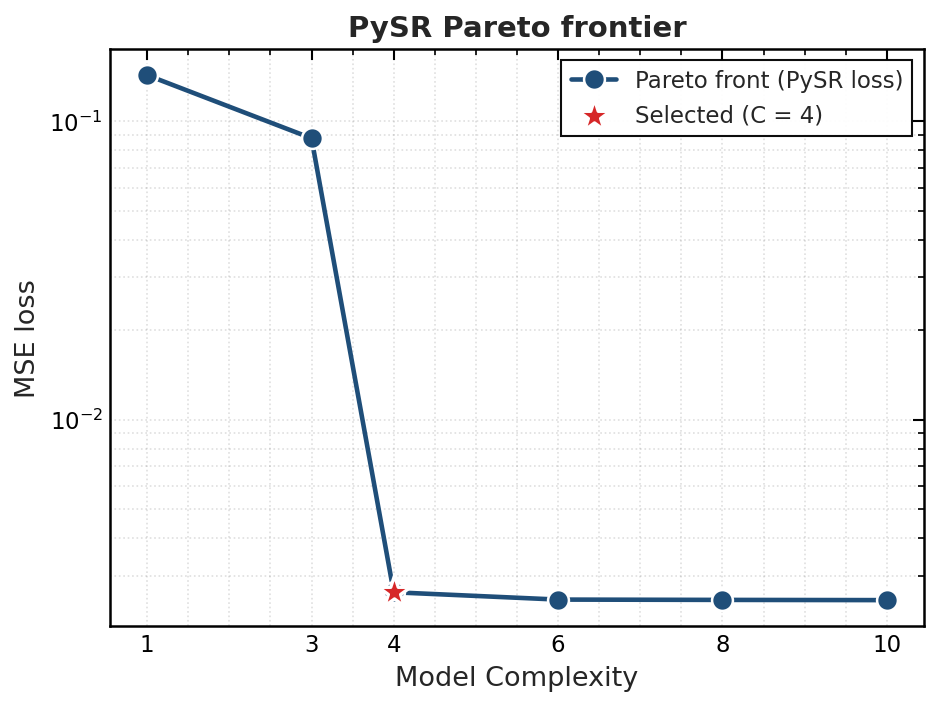

In [12]:
selected_complexity = int(best['complexity'])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
plot_df = pareto_df.sort_values('complexity')
ax.plot(plot_df['complexity'], plot_df['pysr_loss'],
        marker='o', markersize=10, linewidth=2.2,
        color='#1f4e79', label='Pareto front (PySR loss)',
        markerfacecolor='#1f4e79', markeredgecolor='white',
        markeredgewidth=1.2, zorder=2)
sel_row = plot_df[plot_df['complexity'] == selected_complexity].iloc[0]
ax.scatter([sel_row['complexity']], [sel_row['pysr_loss']],
           s=260, color='#d62728', marker='*',
           edgecolor='white', linewidth=1.6, zorder=5,
           label=f'Selected (C = {selected_complexity})')
ax.set_xlabel('Model Complexity')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.set_xticks(sorted(plot_df['complexity'].unique()))
ax.set_title('PySR Pareto frontier')
ax.grid(True, alpha=0.25, linestyle=':', which='both')
ax.legend(loc='upper right')
fig.savefig(RESULTS_DIR / 'pareto_frontier.png')
plt.show()


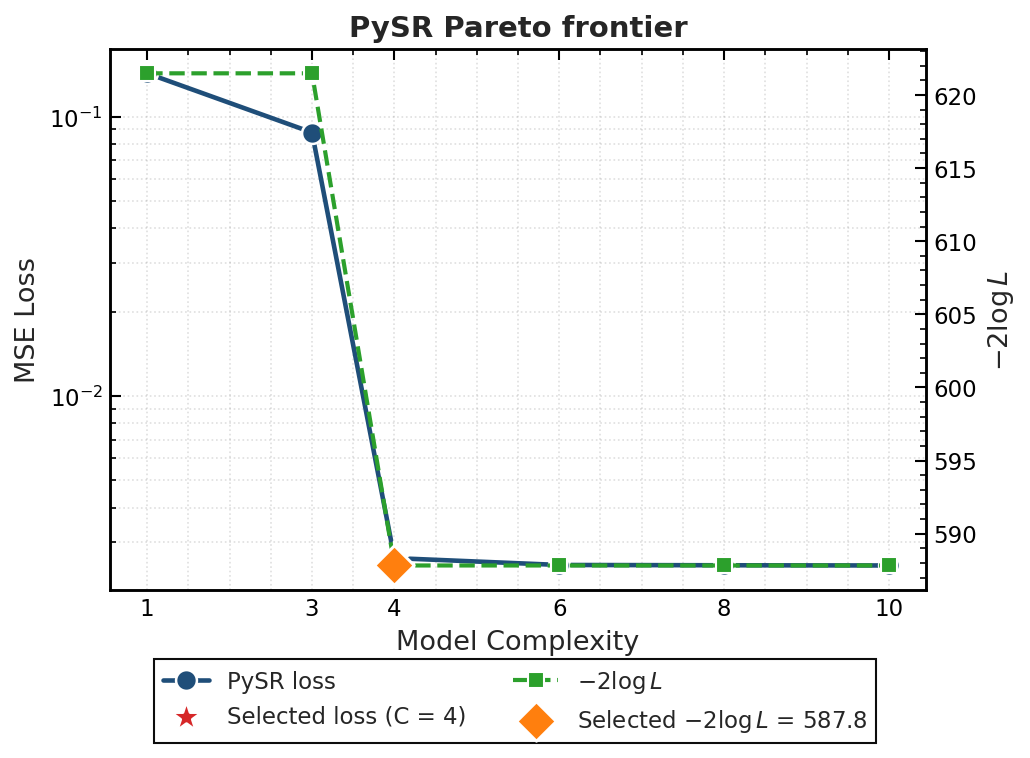

In [13]:

selected_complexity = int(best['complexity'])

fig, ax1 = plt.subplots(figsize=FIGSIZE_SINGLE)

plot_df = pareto_df.sort_values('complexity').copy()

# -----------------------------
# Left axis: PySR loss
# -----------------------------
ax1.plot(
    plot_df['complexity'],
    plot_df['pysr_loss'],
    marker='o',
    markersize=10,
    linewidth=2.2,
    color='#1f4e79',
    label='PySR loss',
    markerfacecolor='#1f4e79',
    markeredgecolor='white',
    markeredgewidth=1.2,
    zorder=2
)

# Safer selection: use idx_eq if available, otherwise use complexity
if 'idx_eq' in best.index and 'idx_eq' in plot_df.columns:
    sel_row = plot_df[plot_df['idx_eq'] == int(best['idx_eq'])].iloc[0]
else:
    sel_row = plot_df[plot_df['complexity'] == selected_complexity].iloc[0]

ax1.scatter(
    [sel_row['complexity']],
    [sel_row['pysr_loss']],
    s=260,
    color='#d62728',
    marker='*',
    edgecolor='white',
    linewidth=1.6,
    zorder=5,
    label=f'Selected loss (C = {selected_complexity})'
)

ax1.set_xlabel('Model Complexity')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')
ax1.set_xticks(sorted(plot_df['complexity'].unique()))
ax1.grid(True, alpha=0.25, linestyle=':', which='both')


# -----------------------------
# Right axis: likelihood score
# -----------------------------
ax2 = ax1.twinx()

ax2.plot(
    plot_df['complexity'],
    plot_df['neg2_log_likelihood'],
    marker='s',
    markersize=8,
    linewidth=2.0,
    linestyle='--',
    color='#2ca02c',
    label=r'$-2\log L$',
    markerfacecolor='#2ca02c',
    markeredgecolor='white',
    markeredgewidth=1.0,
    zorder=3
)

ax2.scatter(
    [sel_row['complexity']],
    [sel_row['neg2_log_likelihood']],
    s=180,
    color='#ff7f0e',
    marker='D',
    edgecolor='white',
    linewidth=1.4,
    zorder=6,
    label=rf'Selected $-2\log L$ = {sel_row["neg2_log_likelihood"]:.1f}'
)

ax2.set_ylabel(r'$-2\log L$')
ax2.grid(False)


# -----------------------------
# Combined legend outside plot
# -----------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=True
)

ax1.set_title('PySR Pareto frontier')

# Leave space at bottom for legend
fig.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    RESULTS_DIR / 'pareto_frontier_loss_likelihood.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Step 11 — 5-fold stratified cross-validation on `val_cv`

The CV pool is **`val_cv` only** (37.5 % of total). Train data is deliberately excluded — that's the data PySR fitted on, and including it would inflate CV metrics.

For each fold, the equation is frozen and `t` is re-calibrated on the fold's training portion. This gives us a stability band around the final calibrated thresholds.


In [14]:
X_pool = X_val_cv
y_pool = y_val_cv
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_records, fold_cms, fold_predictions = [], [], []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_pool, y_pool), start=1):
    s_tr = score_fn(X_pool[tr_idx].ravel())
    s_te = score_fn(X_pool[te_idx].ravel())
    _, t_fold = optimize_thresholds(s_tr, y_pool[tr_idx], grid=40)
    yp = classify_scores(s_te, t_fold)

    cm = confusion_matrix(y_pool[te_idx], yp, labels=LABEL_ORDER, normalize='true')
    fold_cms.append(cm)
    fold_records.append({
        'fold':      fold,
                't': float(t_fold),
                'accuracy':  accuracy_score(y_pool[te_idx], yp),
        'precision': precision_score(y_pool[te_idx], yp, average='macro', zero_division=0),
        'recall':    recall_score(y_pool[te_idx], yp, average='macro', zero_division=0),
        'f1':        f1_score(y_pool[te_idx], yp, average='macro'),
    })
    fold_predictions.append((X_pool[te_idx].ravel(), y_pool[te_idx], yp))

cv_df = pd.DataFrame(fold_records)
cv_summary = cv_df.drop(columns=['fold']).agg(['mean', 'std'])
cv_df.to_csv(RESULTS_DIR / 'cv_folds.csv', index=False)
cv_summary.to_csv(RESULTS_DIR / 'cv_summary.csv')

print('Per-fold:'); print(cv_df.to_string(index=False))
print('\n5-fold CV summary (mean ± std):')
for m in ['accuracy', 'precision', 'recall', 'f1']:
    print(f'  {m:10s}: {cv_df[m].mean():.4f} ± {cv_df[m].std():.4f}')
print(f'  t         : {cv_df["t"].mean():.4f} ± {cv_df["t"].std():.4f}')


Per-fold:
 fold        t  accuracy  precision  recall      f1
    1 0.459737   0.99815   0.998157 0.99815 0.99815
    2 0.459739   0.99750   0.997512 0.99750 0.99750
    3 0.459746   0.99800   0.998008 0.99800 0.99800
    4 0.459738   0.99805   0.998058 0.99805 0.99805
    5 0.459743   0.99835   0.998355 0.99835 0.99835

5-fold CV summary (mean ± std):
  accuracy  : 0.9980 ± 0.0003
  precision : 0.9980 ± 0.0003
  recall    : 0.9980 ± 0.0003
  f1        : 0.9980 ± 0.0003
  t         : 0.4597 ± 0.0000


## Step 12a — Frozen evaluation on TEST

Frozen equation + calibrated `t` applied to TEST. The test set has been untouched by every previous decision.


In [15]:
t_mean = float(cv_df["t"].mean())
print(f"CV-mean threshold: t = {t_mean:.4f}")


CV-mean threshold: t = 0.4597


In [16]:
z_test = X_test.ravel()
s_test = score_fn(z_test)
y_pred = classify_scores(s_test, t_mean)

acc_t  = accuracy_score(y_test, y_pred)
prec_t = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_t  = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_t   = f1_score(y_test, y_pred, average='macro')

pc_p, pc_r, pc_f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=LABEL_ORDER, zero_division=0)
cm_test_raw  = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
cm_test_norm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER, normalize='true')

print(f'TEST  n = {len(y_test):,}   (CV-mean threshold: t={t_mean:.4f})')
print(f'  Accuracy          : {acc_t:.4f}')
print(f'  Precision (macro) : {prec_t:.4f}')
print(f'  Recall    (macro) : {rec_t:.4f}')
print(f'  F1        (macro) : {f1_t:.4f}')
print()
print(classification_report(y_test, y_pred, labels=LABEL_ORDER,
                            target_names=CLASSES, digits=4, zero_division=0))


TEST  n = 20,000   (CV-mean threshold: t=0.4597)
  Accuracy          : 0.9979
  Precision (macro) : 0.9979
  Recall    (macro) : 0.9979
  F1        (macro) : 0.9978

              precision    recall  f1-score   support

      GALAXY     1.0000    0.9957    0.9978     10000
        STAR     0.9957    1.0000    0.9979     10000

    accuracy                         0.9979     20000
   macro avg     0.9979    0.9979    0.9978     20000
weighted avg     0.9979    0.9979    0.9978     20000



### Step 12b — TEST metrics across all CV-fold thresholds

The thresholds `t_mean` used above are the mean of the 5 CV folds. Below we re-evaluate the **frozen equation on TEST** using *each* fold's own thresholds, so we can report the mean ± std of every classification metric. This quantifies how sensitive the final test-set numbers are to small perturbations in `t`.


In [17]:
# Re-evaluate TEST using each CV fold's t and tabulate mean +/- std
_test_rows = []
for _, _r in cv_df.iterrows():
    _yp = classify_scores(s_test, float(_r['t']))
    _test_rows.append({
        'fold':      int(_r['fold']),
        't': float(_r['t']),
                'accuracy':  accuracy_score(y_test, _yp),
        'precision': precision_score(y_test, _yp, average='macro', zero_division=0),
        'recall':    recall_score(y_test, _yp, average='macro', zero_division=0),
        'f1':        f1_score(y_test, _yp, average='macro'),
    })
test_fold_metrics_df = pd.DataFrame(_test_rows)

print('TEST metrics across {} fold t values:'.format(len(test_fold_metrics_df)))
print(test_fold_metrics_df.to_string(index=False, float_format='%.4f'))
print()
print('Summary (mean +/- std, ddof=1):')
test_summary_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1'],
    'mean':   [test_fold_metrics_df[m].mean() for m in ['accuracy','precision','recall','f1']],
    'std':    [test_fold_metrics_df[m].std(ddof=1) for m in ['accuracy','precision','recall','f1']],
})
print(test_summary_df.to_string(index=False, float_format='%.4f'))

test_fold_metrics_df.to_csv(RESULTS_DIR / 'test_metrics_per_fold.csv', index=False)
test_summary_df.to_csv(RESULTS_DIR / 'test_metrics_summary.csv', index=False)


TEST metrics across 5 fold t values:
 fold      t  accuracy  precision  recall     f1
    1 0.4597    0.9979     0.9979  0.9979 0.9978
    2 0.4597    0.9979     0.9979  0.9979 0.9978
    3 0.4597    0.9979     0.9979  0.9979 0.9978
    4 0.4597    0.9979     0.9979  0.9979 0.9978
    5 0.4597    0.9979     0.9979  0.9979 0.9978

Summary (mean +/- std, ddof=1):
   metric   mean    std
 accuracy 0.9979 0.0000
precision 0.9979 0.0000
   recall 0.9979 0.0000
       f1 0.9978 0.0000


## Step 12c — Confusion matrices: CV (val_cv mean) vs. TEST

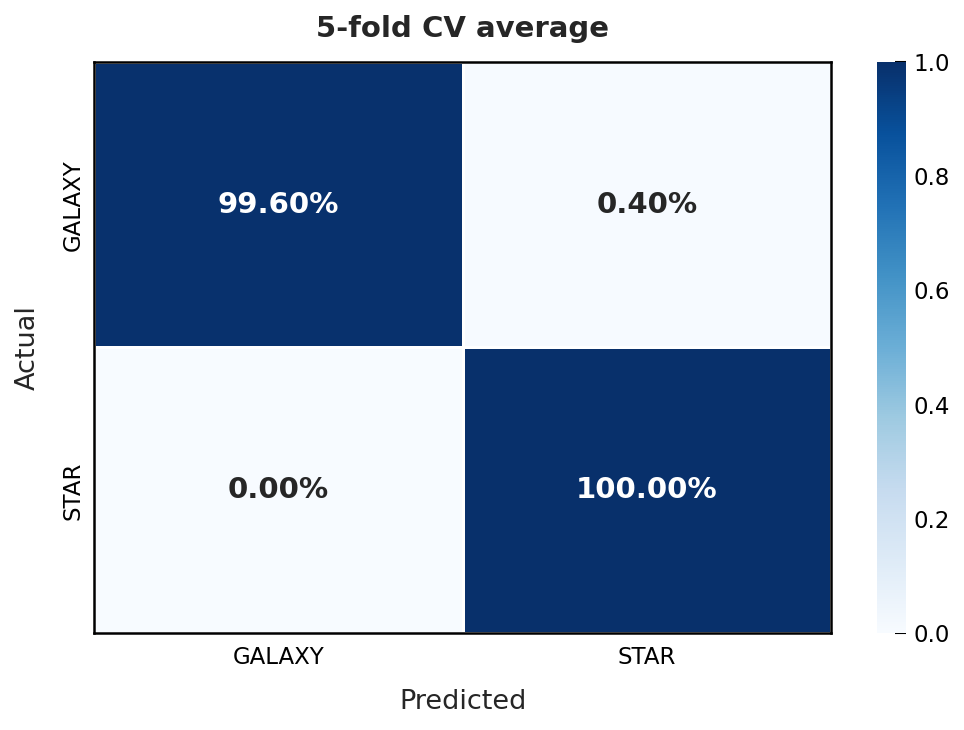

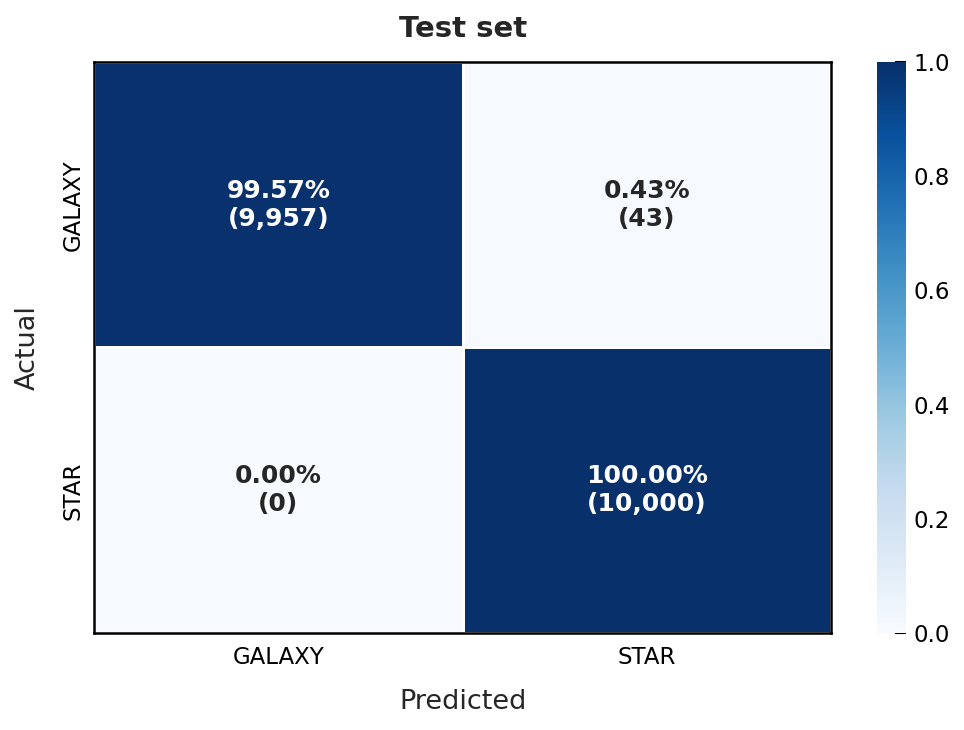

In [18]:
mean_cm = np.mean(fold_cms, axis=0)
cm_test = cm_test_norm

def _pct_annot(M_norm):
    return np.array([[f'{100*v:.2f}%' for v in row] for row in M_norm])

def _pct_count_annot(M_norm, M_count):
    return np.array([
        [f'{100*M_norm[i, j]:.2f}%' + chr(10) + f'({int(M_count[i, j]):,})'
         for j in range(M_norm.shape[1])]
        for i in range(M_norm.shape[0])
    ])

# --- CV mean (row-normalized fractions, no raw counts available) ---
fig, ax = plt.subplots(figsize=(7.0, 5.0))
sns.heatmap(mean_cm, annot=_pct_annot(mean_cm), fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar=True, vmin=0, vmax=1,
            annot_kws={'size': 14, 'weight': 'bold'},
            linewidths=0.6, linecolor='white')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual',    labelpad=10)
ax.set_title('5-fold CV average', fontweight='bold', pad=12)
plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
ax.tick_params(axis='y', pad=10)
ax.tick_params(axis='x', pad=6)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrix_cv.png')
plt.show()

# --- TEST (percentage on top, count in brackets) ---
fig, ax = plt.subplots(figsize=(7.0, 5.0))
sns.heatmap(cm_test, annot=_pct_count_annot(cm_test, cm_test_raw),
            fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar=True, vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'},
            linewidths=0.6, linecolor='white')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual',    labelpad=10)
ax.set_title('Test set', fontweight='bold', pad=12)
plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
ax.tick_params(axis='y', pad=10)
ax.tick_params(axis='x', pad=6)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrix_test.png')
plt.show()


## Step 12d — Macro F1 vs threshold `t` on `val_cv`

Sweep the single decision threshold `t` over `[P_5, P_{95}]` of the symbolic score on `val_cv` and plot macro-F1 as a function of `t`. The CV-mean threshold `t_mean` is marked with a vertical line.


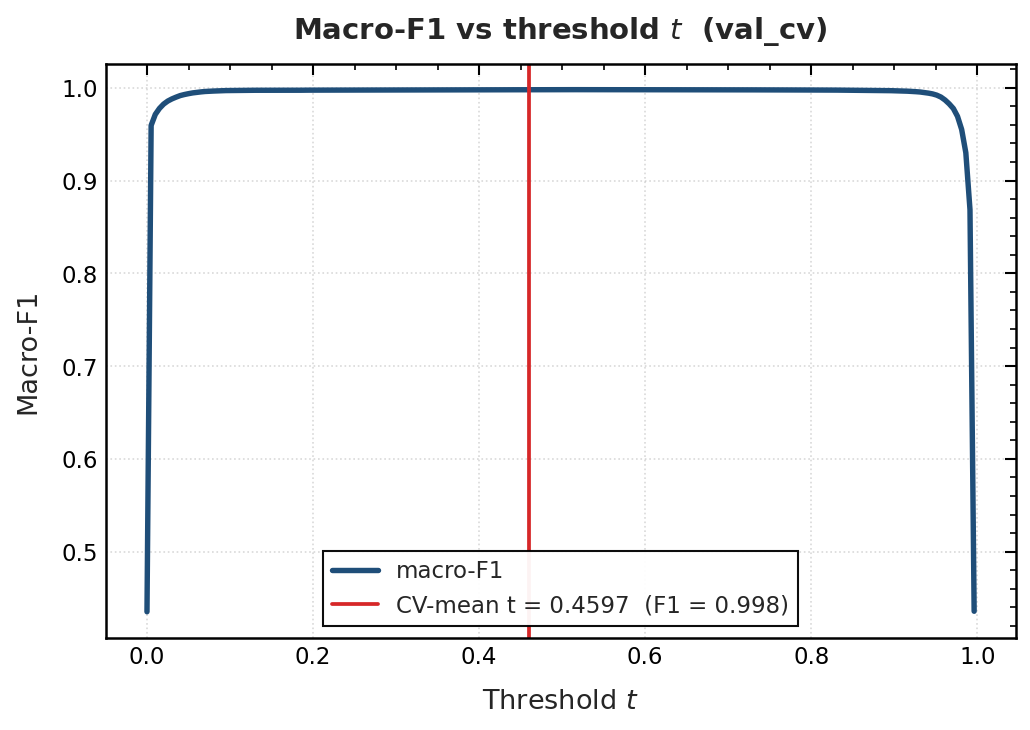

In [19]:
s_val_chk = score_fn(X_val_cv.ravel())

# Compute macro-F1 at the chosen t_mean on val_cv
y_pred_at_mean = classify_scores(s_val_chk, t_mean)
f1_calib = f1_score(y_val_cv, y_pred_at_mean, average='macro')

lo, hi = np.percentile(s_val_chk, [5, 95])
G = 200
ts = np.linspace(lo, hi, G)
F1_curve = np.array([
    f1_score(y_val_cv, classify_scores(s_val_chk, t), average='macro')
    for t in ts
])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.plot(ts, F1_curve, '-', color='#1f4e79', lw=2.6, label='macro-F1')
ax.axvline(t_mean, color='#d62728', lw=1.8,
           label=f'CV-mean t = {t_mean:.4f}  (F1 = {f1_calib:.3f})')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlabel('Threshold $t$', labelpad=10)
ax.set_ylabel('Macro-F1', labelpad=10)
ax.set_title('Macro-F1 vs threshold $t$  (val_cv)',
             fontweight='bold', pad=12)
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='lower center', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'macro_f1_vs_threshold.png', dpi=200)
plt.show()


## Step 12e — Error analysis on TEST and CV data

Two panels:

- **Left (log-y).** Stacked histograms of correctly classified objects
  (grey) and misclassified ones (red) across $z$.
- **Right.** Binned error rate
  $z \mapsto \mathbb{E}[\mathbb{1}_{y \ne \hat y}\mid z]$.

The right-panel peak typically sits near $z \approx 1$, where galaxy and QSO populations physically overlap. This is an information-theoretic floor for a 1-D classifier — not a defect of the discovered equation.


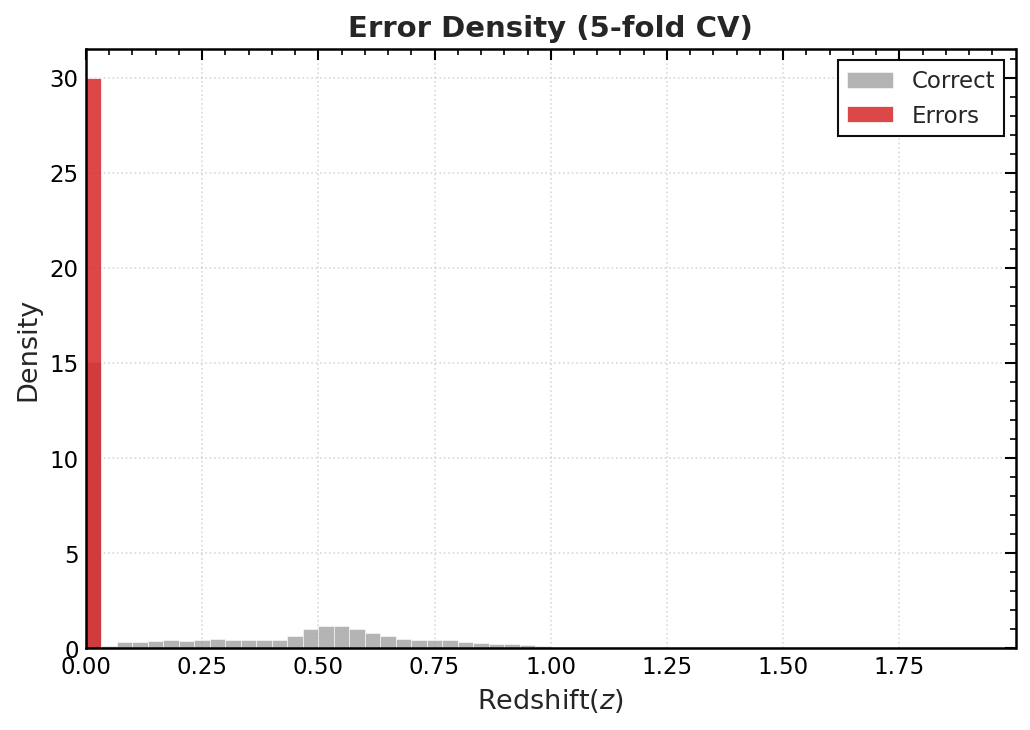

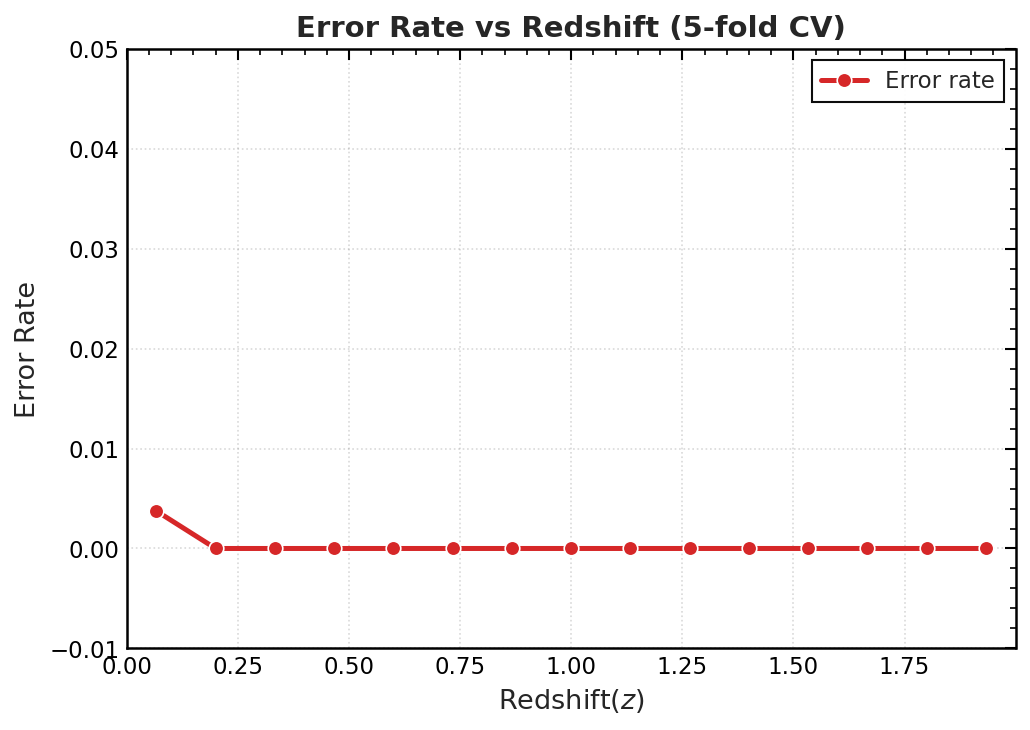

In [20]:
# Pool every fold's held-out predictions: one prediction per val_cv row.
z_cv      = np.concatenate([z  for z, _, _ in fold_predictions])
y_cv_true = np.concatenate([yt for _, yt, _ in fold_predictions])
y_cv_pred = np.concatenate([yp for _, _, yp in fold_predictions])

errors_cv = y_cv_pred != y_cv_true

# Full redshift range (paper convention)
zmax_cv          = float(np.quantile(z_cv, PLOT_Z_QUANTILE))
bins_density_cv  = np.linspace(0.0, zmax_cv, PLOT_N_BINS_DENSITY + 1)
bins_rate_cv     = np.linspace(0.0, zmax_cv, PLOT_N_BINS_RATE + 1)
bcent_rate_cv    = 0.5 * (bins_rate_cv[:-1] + bins_rate_cv[1:])

err_rate_cv, n_cv = binned_error_rate_paper(
    z_cv, errors_cv, bins_rate_cv, min_count=1, zero_fill=True)

# ---- Figure 1: redshift density of correct vs error predictions ----------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.hist(z_cv[~errors_cv], bins=bins_density_cv, density=True,
        alpha=0.65, color='0.55', edgecolor='white', linewidth=0.4,
        label='Correct')
ax.hist(z_cv[errors_cv],  bins=bins_density_cv, density=True,
        alpha=0.85, color='#d62728', edgecolor='white', linewidth=0.4,
        label='Errors')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_cv)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Density')
ax.set_title('Error Density (5-fold CV)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_density_val_cv.png', dpi=200)
plt.show()

# ---- Figure 2: per-bin error rate, coarse bins, marker-line, zero-fill ----
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.plot(bcent_rate_cv, err_rate_cv, color='#d62728', linewidth=2.4,
        marker='o', markersize=7, markerfacecolor='#d62728',
        markeredgecolor='white', markeredgewidth=0.8,
        label='Error rate', zorder=5)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_cv); ax.set_ylim(-0.01, max(0.05, np.nanmax(err_rate_cv) * 1.15))
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Error Rate')
ax.set_title('Error Rate vs Redshift (5-fold CV)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_rate_val_cv.png', dpi=200)
plt.show()


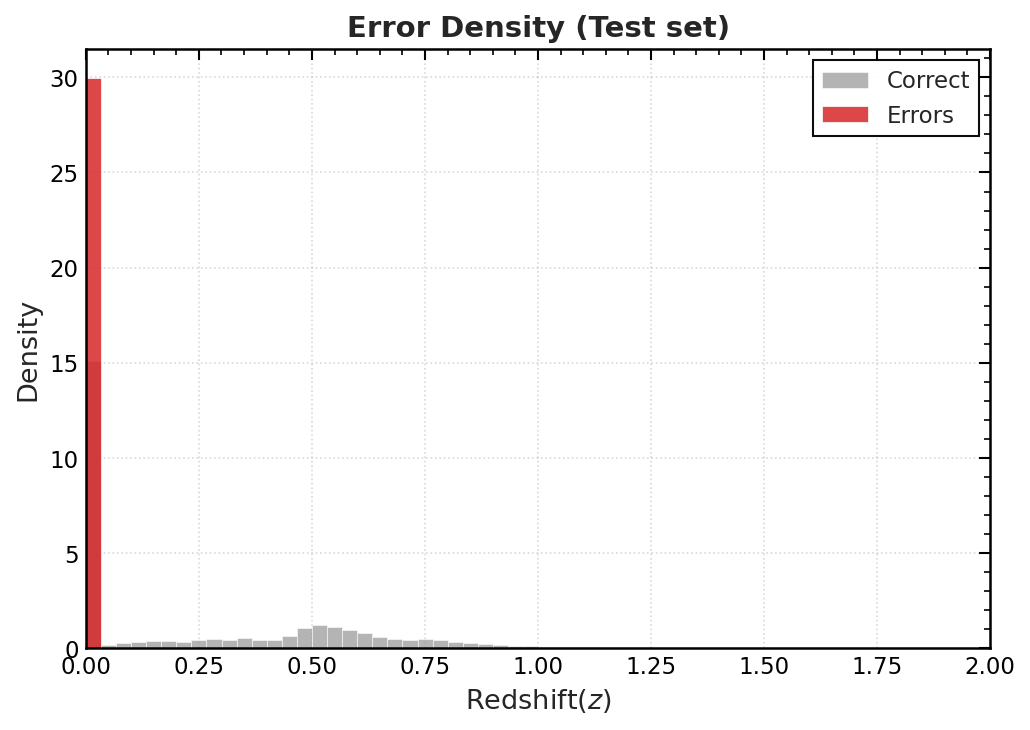

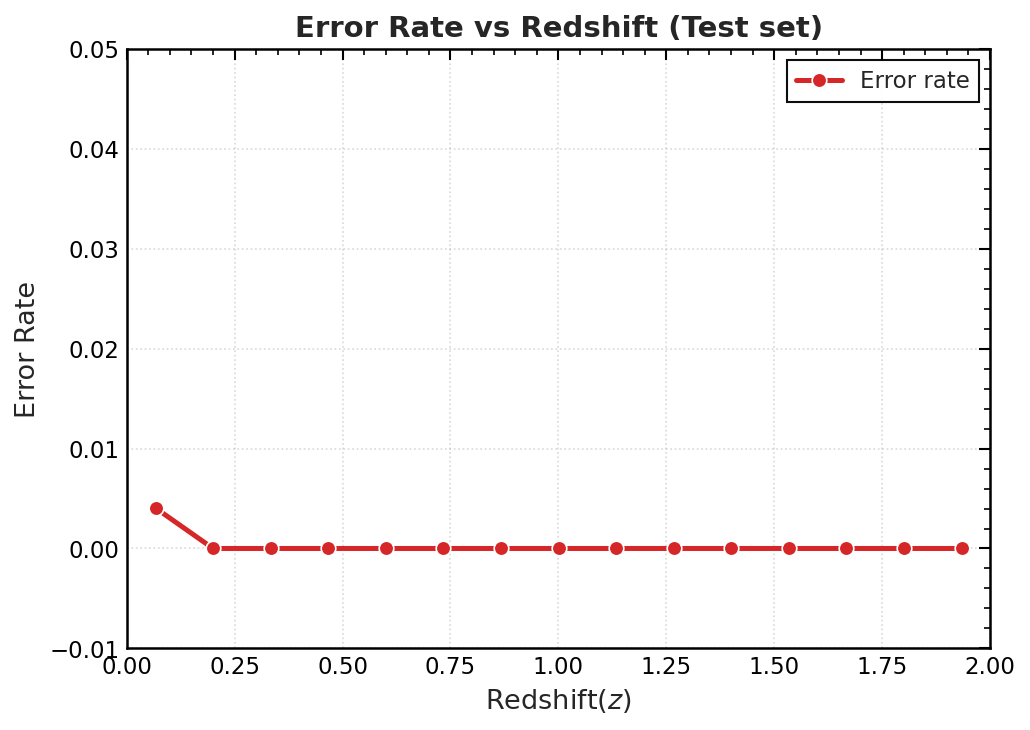

In [21]:
errors_t = y_pred != y_test

zmax_t          = float(np.quantile(z_test, PLOT_Z_QUANTILE))
bins_density_t  = np.linspace(0.0, zmax_t, PLOT_N_BINS_DENSITY + 1)
bins_rate_t     = np.linspace(0.0, zmax_t, PLOT_N_BINS_RATE + 1)
bcent_rate_t    = 0.5 * (bins_rate_t[:-1] + bins_rate_t[1:])

err_rate_t, n_t = binned_error_rate_paper(
    z_test, errors_t, bins_rate_t, min_count=1, zero_fill=True)

# ---- Figure 1: redshift density of correct vs error predictions ----------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.hist(z_test[~errors_t], bins=bins_density_t, density=True,
        alpha=0.65, color='0.55', edgecolor='white', linewidth=0.4,
        label='Correct')
ax.hist(z_test[errors_t],  bins=bins_density_t, density=True,
        alpha=0.85, color='#d62728', edgecolor='white', linewidth=0.4,
        label='Errors')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_t)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Density')
ax.set_title('Error Density (Test set)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_density_test.png', dpi=300)
plt.show()

# ---- Figure 2: per-bin error rate -----------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.plot(bcent_rate_t, err_rate_t, color='#d62728', linewidth=2.4,
        marker='o', markersize=7, markerfacecolor='#d62728',
        markeredgecolor='white', markeredgewidth=0.8,
        label='Error rate', zorder=5)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_t); ax.set_ylim(-0.01, max(0.05, np.nanmax(err_rate_t) * 1.15))
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Error Rate')
ax.set_title('Error Rate vs Redshift (Test set)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_rate_test.png', dpi=300)
plt.show()


## Step 12f — Recall vs. redshift

Per-class recall in fine $z$-bins, with shaded $\pm 1\sigma$ bands from the 5 CV folds:

- **Linear-$z$** (clipped to $z \le 2.5$) — shows the galaxy plateau and
  the galaxy → QSO crossover near $z \approx 1$ at high resolution.
- **Log-$z$** — needed to resolve the stellar locus, which lives at
  $z \in [10^{-5},\ 10^{-3}]$ and would otherwise collapse into a single
  pixel on the linear axis.

A thin std band is the test we're after — it says the result is stable across folds, not riding on a lucky split.


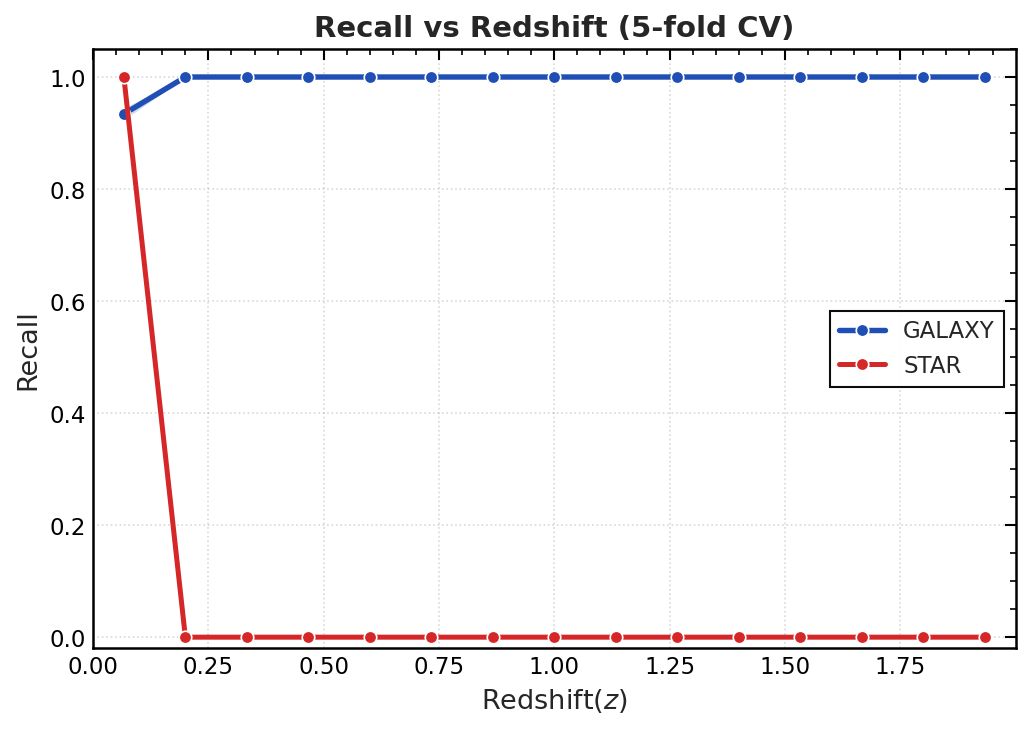

In [22]:
# CV recall vs redshift — paper Figure 12 style: per-fold computation,
# mean +/- 1 sigma across the 5 CV folds. Narrow band where the model is
# stable; widens only at bins where folds genuinely disagree.
z_cv_all = np.concatenate([p[0] for p in fold_predictions])
zmax_cv  = float(np.quantile(z_cv_all, PLOT_Z_QUANTILE))
bins_rec_cv  = np.linspace(0.0, zmax_cv, PLOT_N_BINS_RATE + 1)
bcent_rec_cv = 0.5 * (bins_rec_cv[:-1] + bins_rec_cv[1:])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    cls_id = LABEL_TO_ORD[name]
    per_fold = []
    for z_fold, yt_fold, yp_fold in fold_predictions:
        rec, _ = binned_class_recall_fold_aware(
            z_fold, yt_fold, yp_fold, cls_id, bins_rec_cv, min_count=1)
        per_fold.append(rec)
    mean, std = paper_recall_band(per_fold)

    st = PAPER_CLASS_STYLE[name]
    ax.fill_between(bcent_rec_cv,
                    np.clip(mean - std, 0, 1),
                    np.clip(mean + std, 0, 1),
                    color=st['color'], alpha=0.20, linewidth=0,
                    zorder=st['order'])
    ax.plot(bcent_rec_cv, mean,
            color=st['color'], linewidth=st['lw'],
            marker='o', markersize=6,
            markerfacecolor=st['color'], markeredgecolor='white',
            markeredgewidth=0.8,
            label=name, zorder=st['order'] + 5)

for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_cv); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Recall')
ax.set_title('Recall vs Redshift (5-fold CV)',
             fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='center right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'recall_vs_redshift_val_cv.png', dpi=200)
plt.show()


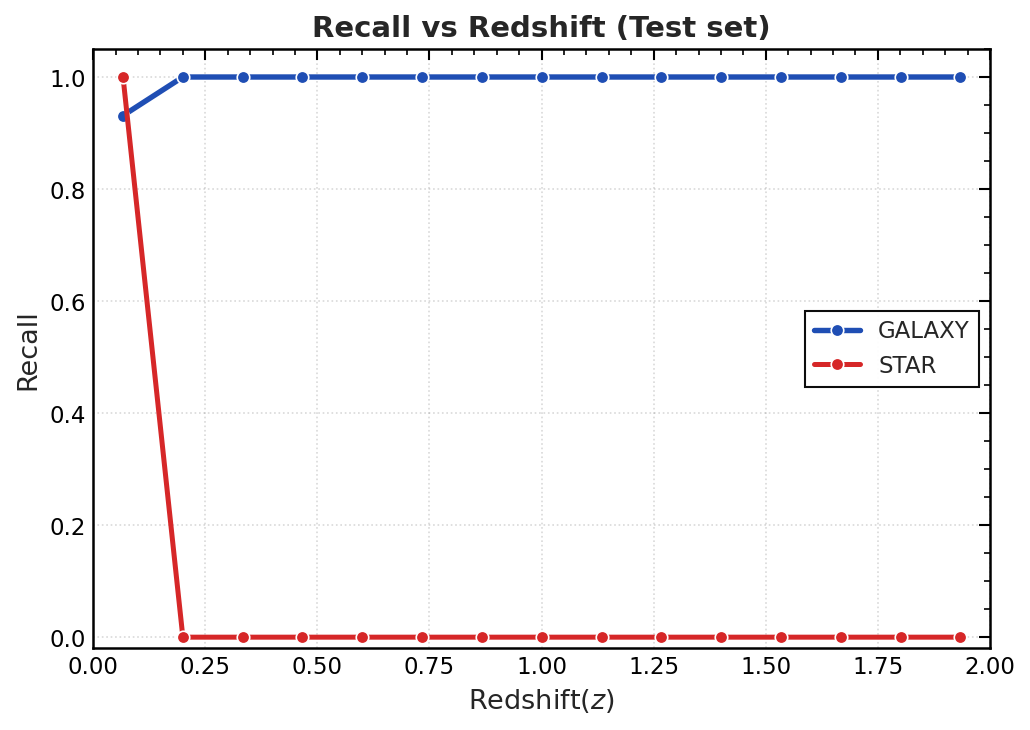

In [23]:
# TEST recall vs redshift — paper-style band built from the 5 CV-fold
# threshold variants. The 5 t values are tightly clustered so the
# band is narrow, matching the paper's "Fig. 12" appearance for stable
# classifiers.
zmax_t      = float(np.quantile(z_test, PLOT_Z_QUANTILE))
bins_rec_t  = np.linspace(0.0, zmax_t, PLOT_N_BINS_RATE + 1)
bcent_rec_t = 0.5 * (bins_rec_t[:-1] + bins_rec_t[1:])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    cls_id = LABEL_TO_ORD[name]
    per_variant = []
    for _, _r in cv_df.iterrows():
        _yp = classify_scores(s_test, float(_r['t']))
        rec, _ = binned_class_recall_fold_aware(
            z_test, y_test, _yp, cls_id, bins_rec_t, min_count=1)
        per_variant.append(rec)
    mean, std = paper_recall_band(per_variant)

    st = PAPER_CLASS_STYLE[name]
    ax.fill_between(bcent_rec_t,
                    np.clip(mean - std, 0, 1),
                    np.clip(mean + std, 0, 1),
                    color=st['color'], alpha=0.20, linewidth=0,
                    zorder=st['order'])
    ax.plot(bcent_rec_t, mean,
            color=st['color'], linewidth=st['lw'],
            marker='o', markersize=6,
            markerfacecolor=st['color'], markeredgecolor='white',
            markeredgewidth=0.8,
            label=name, zorder=st['order'] + 5)

for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_t); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Recall')
ax.set_title('Recall vs Redshift (Test set)',
             fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='center right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'recall_vs_redshift_test.png', dpi=200)
plt.show()


## Step 13a — External evaluation on `photofeatures_exp3.csv`

A second, **completely external** evaluation. We load a different photometric catalogue and apply the frozen $s(z)$ together with the val-calibrated thresholds $t$ — no re-fitting, no recalibration. Anything good about the result has to come from genuine generalisation.

Same preprocessing as Step 1 (label standardisation, NaN drop, ordinal encoding) so labels and feature scales are comparable.


In [24]:
# Load + clean the external catalogue
df_ext = pd.read_csv('./photofeatures_exp3.csv')
df_ext['class'] = df_ext['class'].astype(str).str.upper().replace({'QUASAR': 'QSO'})
df_ext = df_ext.dropna(subset=['class', 'redshift']).reset_index(drop=True)
df_ext = df_ext[df_ext['class'].isin(CLASSES)].reset_index(drop=True)
df_ext['y_ord'] = df_ext['class'].map(LABEL_TO_ORD).astype(int)

print(f'External catalogue rows: {len(df_ext):,}')
print(df_ext['class'].value_counts().to_string())

X_ext       = df_ext[['redshift']].values.astype(float)
y_ext       = df_ext['y_ord'].values.astype(int)
objlist_ext = df_ext['objid'].values
z_ext       = X_ext.ravel()

s_ext = score_fn(z_ext)
y_pred_ext = classify_scores(s_ext, t_mean)

acc_e  = accuracy_score(y_ext, y_pred_ext)
prec_e = precision_score(y_ext, y_pred_ext, average='macro', zero_division=0)
rec_e  = recall_score(y_ext, y_pred_ext, average='macro', zero_division=0)
f1_e   = f1_score(y_ext, y_pred_ext, average='macro')

pc_p_e, pc_r_e, pc_f1_e, support_e = precision_recall_fscore_support(
    y_ext, y_pred_ext, labels=LABEL_ORDER, zero_division=0)
cm_ext_raw  = confusion_matrix(y_ext, y_pred_ext, labels=LABEL_ORDER)
cm_ext_norm = confusion_matrix(y_ext, y_pred_ext, labels=LABEL_ORDER, normalize='true')

print(f'\nEXTERNAL  n = {len(y_ext):,}   (CV-mean threshold: t={t_mean:.4f})')
print(f'  Accuracy          : {acc_e:.4f}')
print(f'  Precision (macro) : {prec_e:.4f}')
print(f'  Recall    (macro) : {rec_e:.4f}')
print(f'  F1        (macro) : {f1_e:.4f}')
print()
print(classification_report(y_ext, y_pred_ext, labels=LABEL_ORDER,
                            target_names=CLASSES, digits=4, zero_division=0))


External catalogue rows: 19,022
class
GALAXY    9511
STAR      9511

EXTERNAL  n = 19,022   (CV-mean threshold: t=0.4597)
  Accuracy          : 0.9992
  Precision (macro) : 0.9992
  Recall    (macro) : 0.9992
  F1        (macro) : 0.9992

              precision    recall  f1-score   support

      GALAXY     1.0000    0.9984    0.9992      9511
        STAR     0.9984    1.0000    0.9992      9511

    accuracy                         0.9992     19022
   macro avg     0.9992    0.9992    0.9992     19022
weighted avg     0.9992    0.9992    0.9992     19022



### Step 13b — EXTERNAL metrics across all CV-fold thresholds

Same diagnostic for the external `photofeatures_exp3` catalogue: re-evaluate the frozen equation using each CV fold's `t` and report mean ± std for every metric. This shows how robust the external-domain numbers are to threshold perturbations.


In [25]:
# Re-evaluate EXTERNAL using each CV fold's t and tabulate mean +/- std
_ext_rows = []
for _, _r in cv_df.iterrows():
    _yp = classify_scores(s_ext, float(_r['t']))
    _ext_rows.append({
        'fold':      int(_r['fold']),
        't':         float(_r['t']),
        'accuracy':  accuracy_score(y_ext, _yp),
        'precision': precision_score(y_ext, _yp, average='macro', zero_division=0),
        'recall':    recall_score(y_ext, _yp, average='macro', zero_division=0),
        'f1':        f1_score(y_ext, _yp, average='macro'),
    })
ext_fold_metrics_df = pd.DataFrame(_ext_rows)

print('EXTERNAL metrics across {} fold t values:'.format(len(ext_fold_metrics_df)))
print(ext_fold_metrics_df.to_string(index=False, float_format='%.4f'))
print()
print('Summary (mean +/- std, ddof=1):')
ext_summary_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1'],
    'mean':   [ext_fold_metrics_df[m].mean() for m in ['accuracy','precision','recall','f1']],
    'std':    [ext_fold_metrics_df[m].std(ddof=1) for m in ['accuracy','precision','recall','f1']],
})
print(ext_summary_df.to_string(index=False, float_format='%.4f'))

ext_fold_metrics_df.to_csv(RESULTS_DIR / 'external_metrics_per_fold.csv', index=False)
ext_summary_df.to_csv(RESULTS_DIR / 'external_metrics_summary.csv', index=False)


EXTERNAL metrics across 5 fold t values:
 fold      t  accuracy  precision  recall     f1
    1 0.4597    0.9992     0.9992  0.9992 0.9992
    2 0.4597    0.9992     0.9992  0.9992 0.9992
    3 0.4597    0.9992     0.9992  0.9992 0.9992
    4 0.4597    0.9992     0.9992  0.9992 0.9992
    5 0.4597    0.9992     0.9992  0.9992 0.9992

Summary (mean +/- std, ddof=1):
   metric   mean    std
 accuracy 0.9992 0.0000
precision 0.9992 0.0000
   recall 0.9992 0.0000
       f1 0.9992 0.0000


## Step 13c — Confusion matrices: TEST vs. EXTERNAL

Side-by-side row-normalised confusion matrices on the same colour scale. If the per-class recall numbers look close across the two panels, the classifier transfers cleanly from the held-out test set to a catalogue it has never seen.


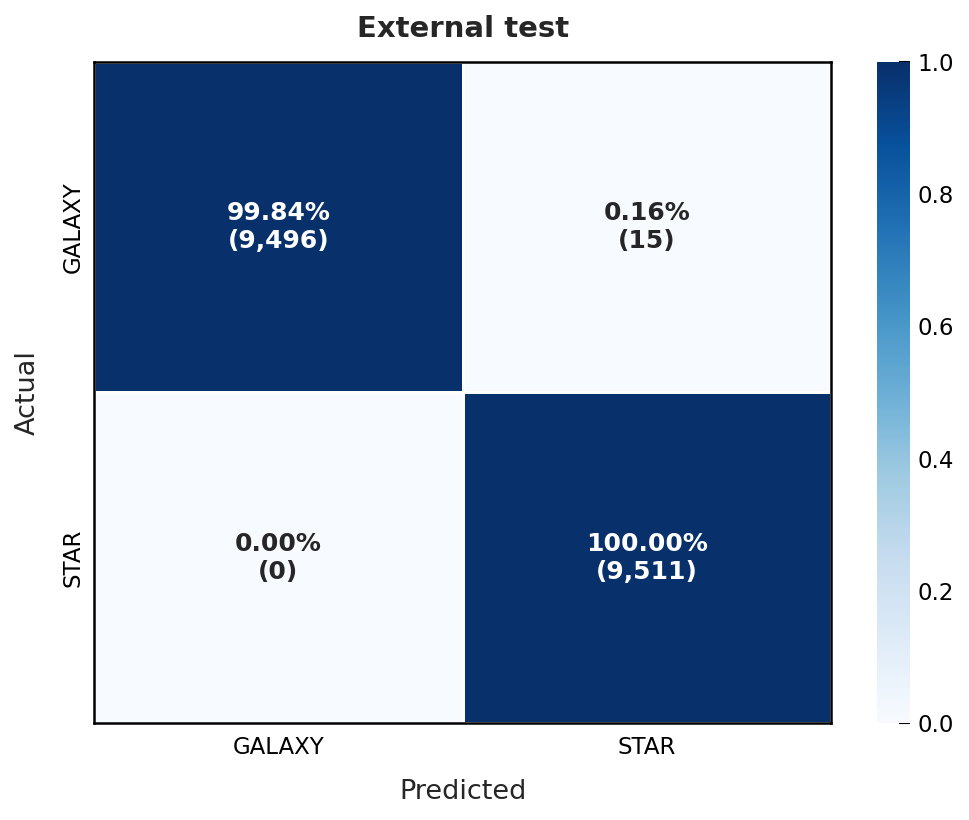

In [26]:
def _pct_count_annot(M_norm, M_count):
    return np.array([
        [f'{100*M_norm[i, j]:.2f}%' + chr(10) + f'({int(M_count[i, j]):,})'
         for j in range(M_norm.shape[1])]
        for i in range(M_norm.shape[0])
    ])

fig, ax = plt.subplots(figsize=(7.0, 5.6))
sns.heatmap(cm_ext_norm, annot=_pct_count_annot(cm_ext_norm, cm_ext_raw),
            fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar=True, vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'},
            linewidths=0.6, linecolor='white')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual',    labelpad=10)
ax.set_title('External test', fontweight='bold', pad=12)
plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
ax.tick_params(axis='y', pad=10)
ax.tick_params(axis='x', pad=6)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrix_external.png')
plt.show()


## Step 13d — Error analysis on EXTERNAL

Same two-panel layout we used for the test set: left shows where errors sit in redshift, right shows the per-bin error rate $z \mapsto \mathbb{E}[\mathbb{1}_{y \ne \hat y}\mid z]$.


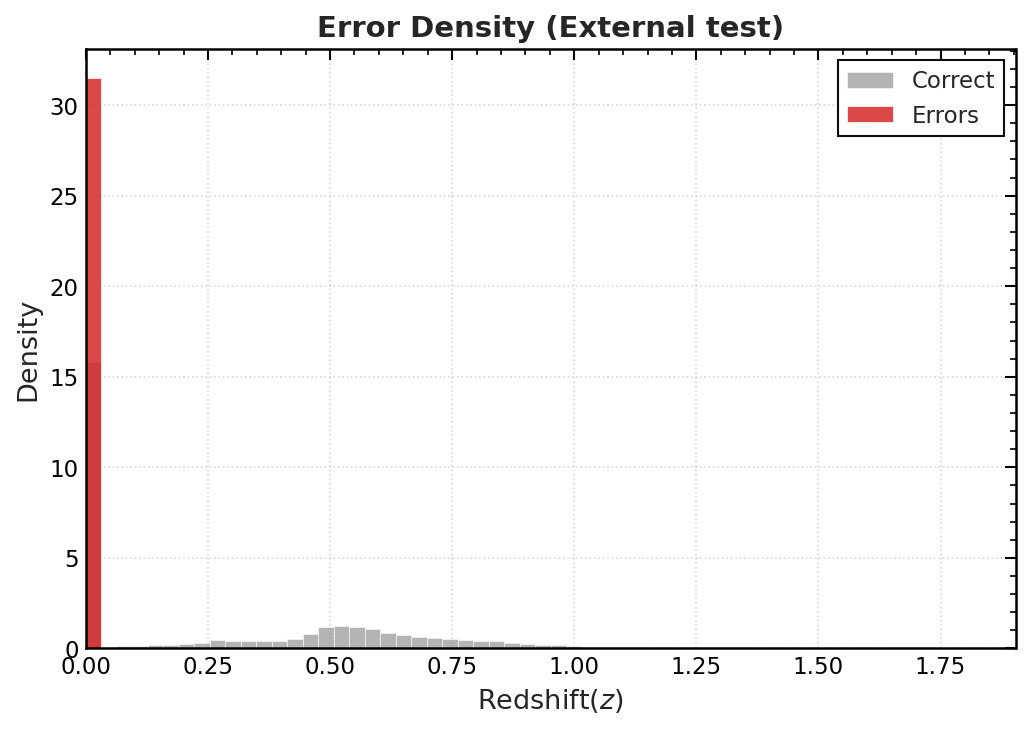

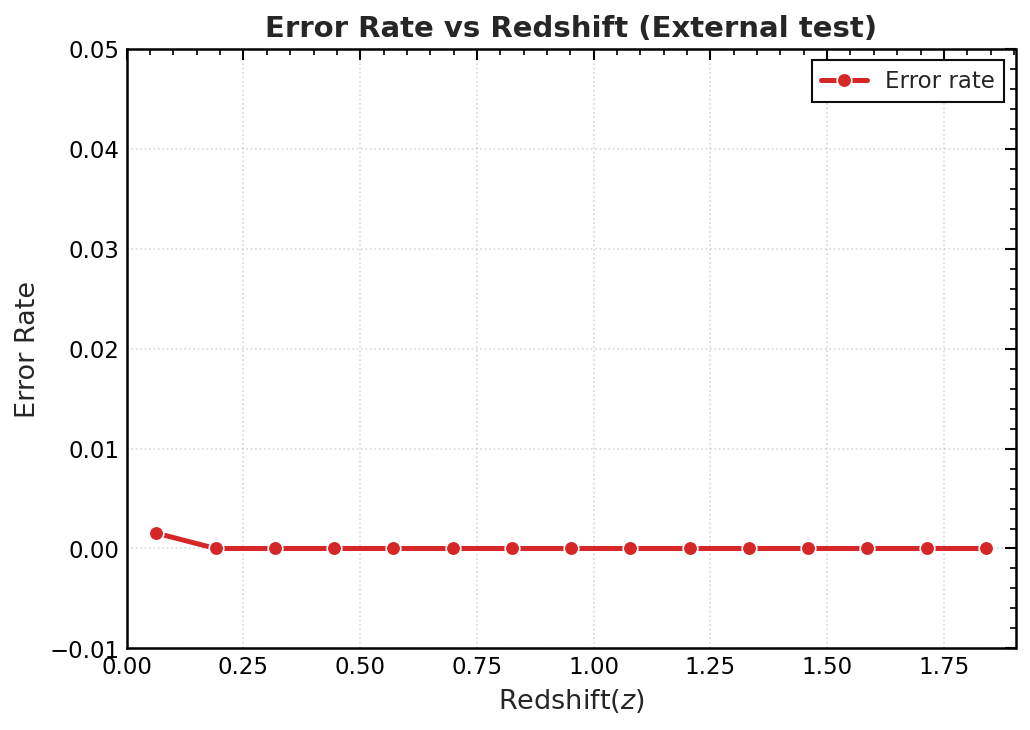

In [27]:
errors_e = y_pred_ext != y_ext

zmax_e          = float(np.quantile(z_ext, PLOT_Z_QUANTILE))
bins_density_e  = np.linspace(0.0, zmax_e, PLOT_N_BINS_DENSITY + 1)
bins_rate_e     = np.linspace(0.0, zmax_e, PLOT_N_BINS_RATE + 1)
bcent_rate_e    = 0.5 * (bins_rate_e[:-1] + bins_rate_e[1:])

err_rate_e, n_e = binned_error_rate_paper(
    z_ext, errors_e, bins_rate_e, min_count=1, zero_fill=True)

# ---- Figure 1: redshift density of correct vs error predictions ----------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.hist(z_ext[~errors_e], bins=bins_density_e, density=True,
        alpha=0.65, color='0.55', edgecolor='white', linewidth=0.4,
        label='Correct')
ax.hist(z_ext[errors_e],  bins=bins_density_e, density=True,
        alpha=0.85, color='#d62728', edgecolor='white', linewidth=0.4,
        label='Errors')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_e)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Density')
ax.set_title('Error Density (External test)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_density_external.png', dpi=200)
plt.show()

# ---- Figure 2: per-bin error rate -----------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.plot(bcent_rate_e, err_rate_e, color='#d62728', linewidth=2.4,
        marker='o', markersize=7, markerfacecolor='#d62728',
        markeredgecolor='white', markeredgewidth=0.8,
        label='Error rate', zorder=5)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_e); ax.set_ylim(-0.01, max(0.05, np.nanmax(err_rate_e) * 1.15))
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Error Rate')
ax.set_title('Error Rate vs Redshift (External test)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_rate_external.png', dpi=300)
plt.show()


## Step 13e — Recall vs. redshift on EXTERNAL

One-shot evaluation, so no $\pm 1\sigma$ fold band — just the central recall curves. We still show both a linear-$z$ panel (clipped to $z \le 2.5$ for galaxy-region resolution) and a log-$z$ panel that resolves the stellar locus.


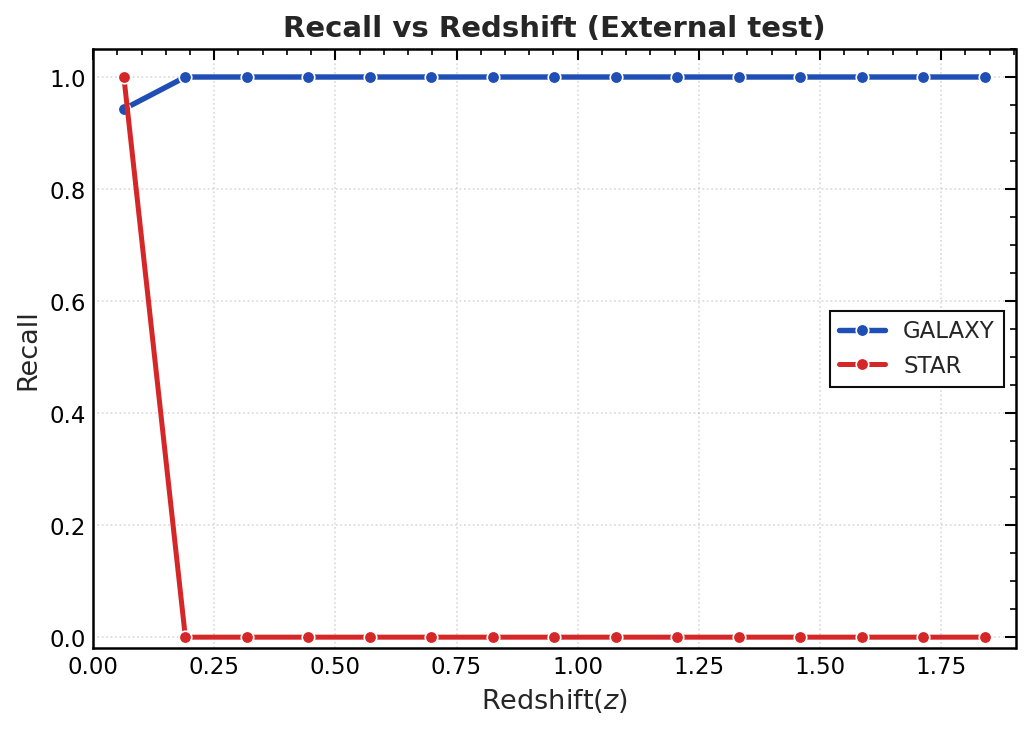

In [28]:
zmax_e      = float(np.quantile(z_ext, PLOT_Z_QUANTILE))
bins_rec_e  = np.linspace(0.0, zmax_e, PLOT_N_BINS_RATE + 1)
bcent_rec_e = 0.5 * (bins_rec_e[:-1] + bins_rec_e[1:])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    cls_id = LABEL_TO_ORD[name]
    per_variant = []
    for _, _r in cv_df.iterrows():
        _yp = classify_scores(s_ext, float(_r['t']))
        rec, _ = binned_class_recall_fold_aware(
            z_ext, y_ext, _yp, cls_id, bins_rec_e, min_count=1)
        per_variant.append(rec)
    mean, std = paper_recall_band(per_variant)

    st = PAPER_CLASS_STYLE[name]
    ax.fill_between(bcent_rec_e,
                    np.clip(mean - std, 0, 1),
                    np.clip(mean + std, 0, 1),
                    color=st['color'], alpha=0.20, linewidth=0,
                    zorder=st['order'])
    ax.plot(bcent_rec_e, mean,
            color=st['color'], linewidth=st['lw'],
            marker='o', markersize=6,
            markerfacecolor=st['color'], markeredgecolor='white',
            markeredgewidth=0.8,
            label=name, zorder=st['order'] + 5)

for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_e); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Recall')
ax.set_title('Recall vs Redshift (External test)',
             fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='center right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'recall_vs_redshift_external.png', dpi=200)
plt.show()


BIC-selected equation : s(z) = exp(-0.0032797274 / x0)
CV-mean threshold     : t = 0.4597


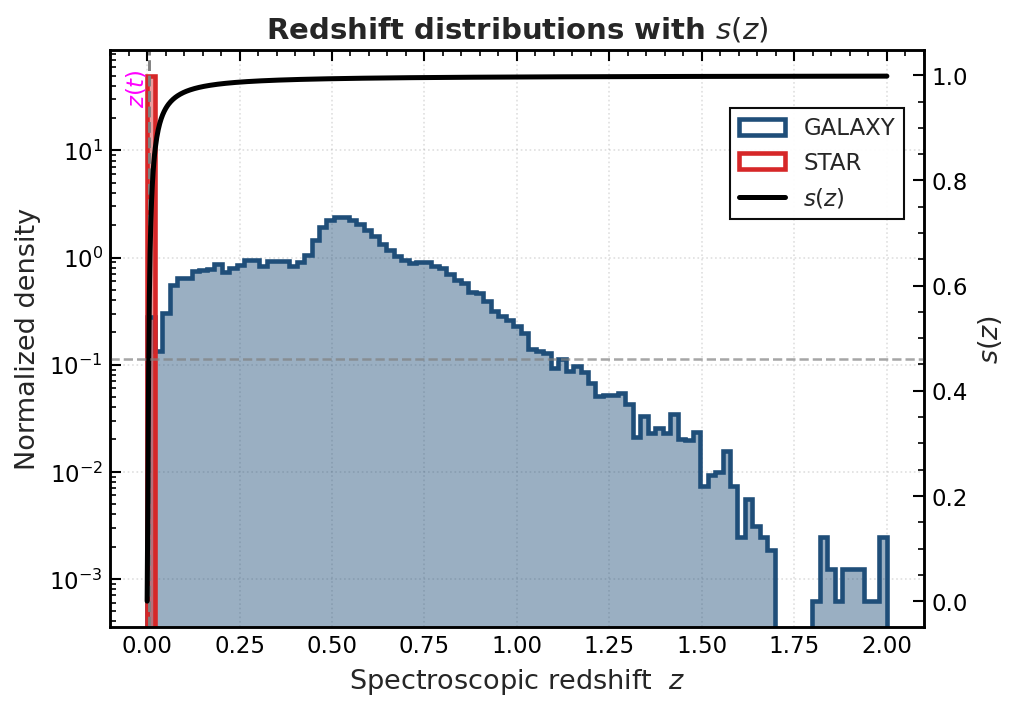

In [29]:
# Per-class redshift distributions with the BIC-selected s(z) overlaid.
# Binary classification: single threshold t.
# Uses score_fn (Step 8) and t_mean (Step 9).

print(f'BIC-selected equation : s(z) = {best_equation_str}')
print(f'CV-mean threshold     : t = {t_mean:.4f}')

zmax   = float(df['redshift'].max())
z_bins = np.linspace(0.0, zmax, 100)
z_grid = np.linspace(0.0, zmax, 1000)
s_grid = score_fn(z_grid)

# Project t back onto the z-axis (defensive sort: monotonic interp)
order    = np.argsort(s_grid)
s_sorted = s_grid[order]
z_sorted = z_grid[order]
z_t = float(np.interp(t_mean, s_sorted, z_sorted)) if (s_sorted.min() <= t_mean <= s_sorted.max()) else None

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = df.loc[df['class'] == name, 'redshift']
    ax.hist(sub, bins=z_bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=z_bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.set_yscale('log')
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('Normalized density')
ax.set_title('Redshift distributions with $s(z)$')
ax.grid(True, alpha=0.25, linestyle=':')

ax_r = ax.twinx()
ax_r.plot(z_grid, s_grid, linewidth=2.4, color='black', label='$s(z)$')
ax_r.set_ylabel('$s(z)$')
ax_r.axhline(t_mean, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

# Project the single threshold back onto the redshift axis
if z_t is not None:
    ax.axvline(z_t, color='gray', linestyle='--', linewidth=1.4)
    ax.text(z_t, ax.get_ylim()[1] / 1.5, '$z(t)$', rotation=90,
            va='top', ha='right', color='magenta')

# Combined legend (class names + s(z) in one box)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax_r.legend(h1 + h2, l1 + l2, loc='upper right' , bbox_to_anchor=(0.99, 0.92))

fig.savefig(RESULTS_DIR / 'redshift_distribution_with_sz.png')
plt.show()


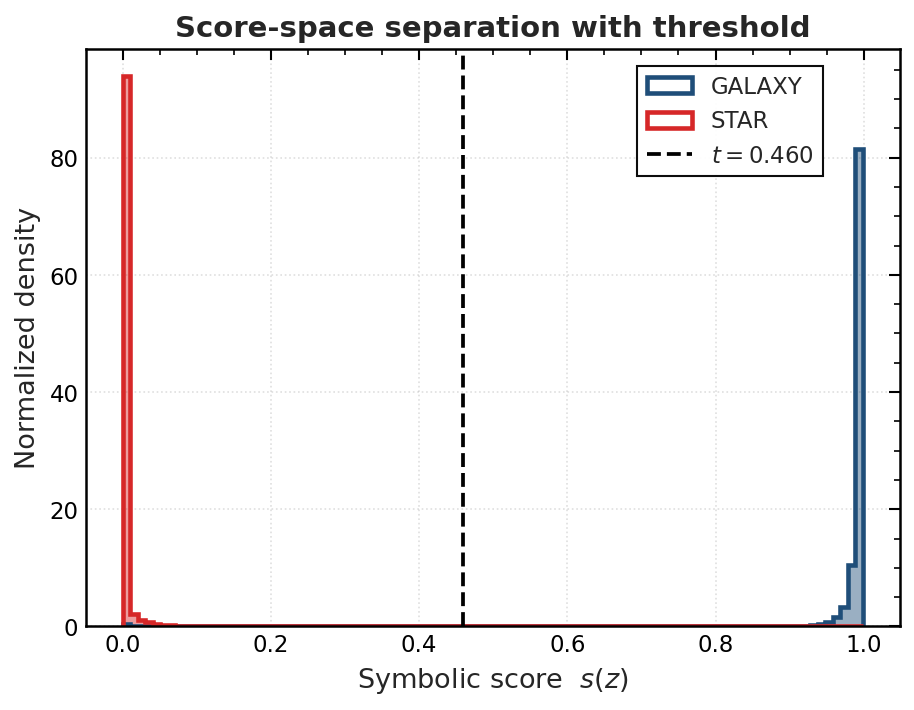

In [30]:
# Score-space (s) per-class histograms with the locked-in threshold.
# Binary classification: single threshold t.
# Uses score_fn (Step 8) and t_mean (Step 9).

s_all  = score_fn(df['redshift'].to_numpy())
s_bins = np.linspace(float(s_all.min()), float(s_all.max()), 100)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = s_all[df['class'].values == name]
    ax.hist(sub, bins=s_bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=s_bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.axvline(t_mean, color='black', linestyle='--', linewidth=1.8,
           label=f'$t = {t_mean:.3f}$')
ax.set_xlabel('Symbolic score  $s(z)$')
ax.set_ylabel('Normalized density')
ax.set_title('Score-space separation with threshold')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend(loc='upper right', bbox_to_anchor=(0.92, 0.99))

fig.savefig(RESULTS_DIR / 'score_distribution_with_threshold.png')
plt.show()